In [8]:
import milaDS
import ds 
import clustering_metrics as cmetrics
import clustering_methods as clustering
import clustering_external_tools as ctools

import ploting as cplt

import os
import numpy as np
import pandas as pd
import re
import random
from openpyxl import Workbook
import gspread
from google.oauth2.service_account import Credentials
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
import gspread
from gspread_dataframe import set_with_dataframe
from google.auth import default
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload


from astropy import units as u
from astropy.stats import biweight_location
from astropy.stats import biweight_scale

from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import calinski_harabasz_score


In [9]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
import importlib
importlib.reload(clustering)
importlib.reload(ctools)
importlib.reload(cmetrics)
importlib.reload(cplt)

<module 'ploting' from 'c:\\Users\\gasep\\OneDrive\\Documentos\\GitHub\\MilaDS\\ploting.py'>

In [11]:
def to_kpc(ra, dec, z, x_center, y_center):
    
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

    dist = cosmo.angular_diameter_distance(z)

    ra = ra - x_center
    dec = dec - y_center

    x = (ra * dist).to(u.Mpc, u.dimensionless_angles()).value

    y = (dec * dist).to(u.Mpc, u.dimensionless_angles()).value

    return x*1000,y*1000

In [12]:
def to_vel(z_gal, z_clus):

    c = const.c.value
    vel = (c*(z_gal - z_clus)/(1 + z_clus))

    return vel

In [13]:
def fix_columns(dfs):

    for i in range(len(dfs)):
        # Split the concatenated column into multiple columns
        split_cols = dfs[i]['# galaxyId haloId haloId_dor ra dec z_app log(m_200)'].str.split(' ', expand=True)

        # Concatenate split_cols with combined_df
        split_df = pd.concat([dfs[i], split_cols], axis=1)

        # Assign appropriate column names
        split_df.columns = ['original_col', 'galaxyId', 'haloId', 'haloId_dor', 'ra', 'dec', 'z_app', 'log(m_200)']

        # Drop the original concatenated column and unnecessary columns
        split_df = split_df.drop(columns=['original_col'])


        numeric_columns = ['galaxyId', 'haloId', 'haloId_dor', 'ra', 'dec', 'z_app', 'log(m_200)']
        split_df[numeric_columns] = split_df[numeric_columns].apply(pd.to_numeric, errors='coerce')
        dfs[i] = split_df
    
    return dfs

In [14]:
def load_data(path):

    files = os.listdir(path)

    # Filter .cat files
    cat_files = [file for file in files if file.endswith('.cat')]

    def extract_number(file_name):
        match = re.search(r'(\d+)', file_name)  # Find the number in the filename
        return int(match.group()) if match else 0  # Return the number as an integer

    cat_files_sorted = sorted(cat_files, key=extract_number)

    # Initialize an empty list to hold individual DataFrames
    dfs = []

    # Loop through each .cat file, read into a DataFrame, and append to the list
    for file in cat_files_sorted:
        file_path = os.path.join(path, file)
        df = pd.read_csv(file_path, delimiter='\t')
        dfs.append(df)

    dfs = fix_columns(dfs)

    
    for df in dfs:
        df['haloId_dor'] = df['haloId_dor'] - 1

    return dfs


In [15]:
def extract_df(data_frame):

    X_data = data_frame.iloc[:,3].values
    Y_data = data_frame.iloc[:,4].values
    Z_data = data_frame.iloc[:,5].values

    #min + (max - min)/2 = (2min + max - min)/2
    x_center = (min(X_data) + max(X_data))/2
    y_center = (min(Y_data) + max(Y_data))/2

    Z_clus = np.mean(Z_data);

    return X_data, Y_data, Z_data, x_center, y_center, Z_clus

Accuracy

In [16]:
def find_dsp_matches(original, dsp, x_center, y_center):

    og_groups = original['haloId_dor'].unique().astype(int)
    dsp_groups = dsp['GrNr'].unique().astype(int)

    closer_matches = np.zeros((len(og_groups),4))

    for g in og_groups:

        if g == 0:
            continue

        closer_matches[g][0] = -1
        closer_matches[g][1] = 0

        members = original[original['haloId_dor'] == g]
        X_members = members.iloc[:,3].values
        Y_members = members.iloc[:,4].values
        Z_members = members.iloc[:,5].values

        Xm_kpc, Ym_kpc = to_kpc(X_members, Y_members, Z_members, x_center, y_center)

        max_matched = 0
        for dspg in dsp_groups: #faster if store matrix instead of searching each iteration

            if dspg == -1:
                continue

            dsp_members = dsp[dsp['GrNr'] == dspg]

            matched = 0
            for id in range(len(Xm_kpc)):

                x = Xm_kpc[id]
                y = Ym_kpc[id]

                found = dsp_members[(dsp_members['x(kpc)'] == x) & (dsp_members['y(kpc)'] == y)]
                
                if len(found) > 0:
                    matched += 1
            
            if matched > max_matched:
                #print('Matches: ', matched, ' OG: ' ,g, ' DS+ group: ', dspg)
                closer_matches[g][0] = dspg
                closer_matches[g][1] = matched

    for id in range(len(closer_matches)):
        members = original[original['haloId_dor'] == id]

        #if closer_matches[id][0] == -1 :
            #continue

        dsp_members = dsp[dsp['GrNr'] == closer_matches[id][0]]

        false_positive = len(dsp_members) - closer_matches[id][1]

        false_negative = len(members) - closer_matches[id][1]

        closer_matches[id][2] = false_positive
        closer_matches[id][3] = false_negative

    columns = ['dpsGr', 'matches', 'false_positives', 'false_negatives']
    matches_df = pd.DataFrame(closer_matches,columns=columns)

    return matches_df
    

In [17]:
def find_ds_matches(indexes, df):

    values = df.loc[indexes, 'haloId_dor']

    matches = (values != 0).sum()
    return matches


In [12]:
mocks_path = "/Users/gasep/OneDrive/Escritorio/Dresler-Schetman/Data/Mocks/clean halos"
dfs = load_data(mocks_path)
members_count_threshold = 300
df_subset = [df for df in dfs if len(df) > members_count_threshold]


In [13]:
def run_algorithms(data, algorithms, params_grid, pertubation_number, original_labels):

    results = []
    lax_original_labels = np.where(original_labels >= 0, 1, -1)

    for params in params_grid:
        alg_results = {}
        for alg in algorithms.keys():

            strict_completitudes = []
            lax_completitudes = []
            strict_purities = []
            lax_purities = []
            strict_f1_scores = []
            lax_f1_scores = []
            strict_rand_indexes = []
            lax_rand_indexes = []
            dunn_indexes = []
            calinski_harabaz_indexes = []

            result = {}

            for i in range(pertubation_number):

                labels, probabilities, clusterer = algorithms[alg](data, params)

                mapped_labels, mapping = ctools.map_values(labels, original_labels)
                print(mapping)
                #print(labels)

                lax_labels = np.where(labels >= 0, 1, -1)

                lax_tp, lax_fp, lax_tn, lax_fn = cmetrics.get_match(lax_original_labels, lax_labels)

                lax_completitudes.append(recall_score(lax_original_labels, lax_labels, average='macro'))

                lax_purities.append(cmetrics.purity_score(lax_original_labels, lax_labels))

                lax_f1_scores.append(f1_score(lax_original_labels, lax_labels, average='macro'))

                lax_rand_indexes.append(cmetrics.get_rand_index(lax_tp, lax_tp + lax_fp, lax_tp + lax_fn))


                tp, fp, tn, fn = cmetrics.get_match(original_labels, mapped_labels)

                strict_completitudes.append(recall_score(original_labels, mapped_labels, average='macro'))

                strict_purities.append(cmetrics.purity_score(original_labels, labels))

                strict_f1_scores.append(f1_score(original_labels, labels, average='macro'))

                strict_rand_indexes.append(cmetrics.get_rand_index(tp, tp + fp, tp + fn))

                dunn_indexes.append(cmetrics.get_dunn_index(data, labels))
                calinski_harabaz_indexes.append(calinski_harabasz_score(data, labels))
                
            result['lax_completitudes_location'] = biweight_location(lax_completitudes)
            result['lax_completitudes_scale'] = biweight_scale(lax_completitudes)
            result['lax_completitudes_mean'] = np.mean(lax_completitudes)
            result['lax_completitudes_std'] = np.std(lax_completitudes)


            result['lax_purity_location'] = biweight_location(lax_purities)
            result['lax_purity_scale'] = biweight_scale(lax_purities)
            result['lax_purity_mean'] = np.mean(lax_purities)
            result['lax_purity_std'] = np.std(lax_purities)

            
            result['lax_f1Score_location'] = biweight_location(lax_f1_scores)
            result['lax_f1Score_scale'] = biweight_scale(lax_f1_scores)
            result['lax_f1Score_mean'] = np.mean(lax_f1_scores)
            result['lax_f1Score_std'] = np.std(lax_f1_scores)

            
            result['lax_randIndex_location'] = biweight_location(lax_rand_indexes)
            result['lax_randIndex_scale'] = biweight_scale(lax_rand_indexes)
            result['lax_randIndex_mean'] = np.mean(lax_rand_indexes)
            result['lax_randIndex_std'] = np.std(lax_rand_indexes)

            
            result['strict_completitudes_location'] = biweight_location(strict_completitudes)
            result['strict_completitudes_scale'] = biweight_scale(strict_completitudes)
            result['strict_completitudes_mean'] = np.mean(strict_completitudes)
            result['strict_completitudes_std'] = np.std(strict_completitudes)


            result['strict_purity_location'] = biweight_location(strict_purities)
            result['strict_purity_scale'] = biweight_scale(strict_purities)
            result['strict_purity_mean'] = np.mean(strict_purities)
            result['strict_purity_std'] = np.std(strict_purities)

            
            result['strict_f1Score_location'] = biweight_location(strict_f1_scores)
            result['strict_f1Score_scale'] = biweight_scale(strict_f1_scores)
            result['strict_f1Score_mean'] = np.mean(strict_f1_scores)
            result['strict_f1Score_std'] = np.std(strict_f1_scores)

            
            result['strict_randIndex_location'] = biweight_location(strict_rand_indexes)
            result['strict_randIndex_scale'] = biweight_scale(strict_rand_indexes)
            result['strict_randIndex_mean'] = np.mean(strict_rand_indexes)
            result['strict_randIndex_std'] = np.std(strict_rand_indexes)


            result['dunnIndex_location'] = biweight_location(dunn_indexes)
            result['dunnIndex_scale'] = biweight_scale(dunn_indexes)
            result['dunnIndex_mean'] = np.mean(dunn_indexes)
            result['dunnIndex_std'] = np.std(dunn_indexes)

            
            result['calinskiHarabazIndex_location'] = biweight_location(calinski_harabaz_indexes)
            result['calinskiHarabazIndex__scale'] = biweight_scale(calinski_harabaz_indexes)
            result['calinskiHarabazIndex__mean'] = np.mean(calinski_harabaz_indexes)
            result['calinskiHarabazIndex__std'] = np.std(calinski_harabaz_indexes)

            alg_results[alg] = result

        results.append(alg_results)
    return results



In [14]:
def save_results_to_xsl(output, params_grid, filename):
    """
    Save clustering results stored in the output dictionary to an Excel file.

    Parameters:
        output: Dictionary where keys are integers (sample index) and values are results.
        params_grid: List of parameter dictionaries for each result set.
        algorithms: Dictionary of algorithms used.
        filename: Name of the Excel file to save.
    """
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for sample_index, results in output.items():
            for i, params in enumerate(params_grid):
                # Create a new sheet for each parameter grid and sample
                sheet_name = f"Cluster_{sample_index} - Params_Set_{i+1}"
                
                # Save parameters as a table at the top of the sheet
                params_table = pd.DataFrame(list(params.items()), columns=["Parameter", "Value"])
                params_table.to_excel(writer, sheet_name=sheet_name, index=False, startrow=0)
                
                start_row = len(params_table) + 2  # Leave some space after the params table
                
                alg_results = results[i]

                for alg, result in alg_results.items():
                    # Add custom text (algorithm key) to the sheet
                    custom_text_df = pd.DataFrame(columns=[alg])
                    custom_text_df.to_excel(writer, sheet_name=sheet_name, index=False, startrow=start_row, header=True)

                    # Prepare the result table for the algorithm
                    result_table = pd.DataFrame(list(result.items()), columns=["Metric", "Value"])
                    
                    # Write algorithm results under the parameters table
                    result_table.to_excel(writer, sheet_name=sheet_name, index=False, startrow=start_row + 1, header=True)
                    
                    # Update start_row for the next algorithm
                    start_row += len(result_table) + 3

    print(f"Results saved to {filename}")

In [15]:
sample_size = 30

df_samples = random.sample(df_subset, sample_size)
df_subset = [df for df in df_subset if not any(df.equals(sample) for sample in df_samples)]

perturbations_number = 1


algorithms = {}

data_frames = {}

params_grid = []

In [16]:
params = {
    "max_clusters" : 40,
    "covariance_type" : 'full',
    "min_cluster_size" : 5,
    "random_state" : 0,
    "min_eps" : 0.5,
    "max_eps" : np.inf,
    "linkage" : 'ward',
    "clustering_threshold" : 0.5,
    'key_point' : 'location'
}

params_grid.append(params)

algorithms['GMM'] = clustering.run_GMM
algorithms['DBSCAN'] = clustering.run_DBSCAN
algorithms['HDBSCAN'] = clustering.run_HDBSCAN
algorithms['Optics'] = clustering.run_OPTICS
algorithms['Kmeans'] = clustering.run_Kmeans
algorithms['Aglomerative'] = clustering.run_Aglomerative_Clustering
algorithms['Affinity'] = clustering.run_Affinity_Propagation

In [26]:
output = {}

filename = "test.xlsx"

for index, c_df in enumerate(df_samples):

    X_data, Y_data, Z_data, x_center, y_center, Z_clus = extract_df(c_df)

    data = np.column_stack((X_data, Y_data))

    original_labels = np.array(c_df.iloc[:, 2].values, dtype=int)    

    results = run_algorithms(data, algorithms, params_grid, perturbations_number, original_labels)    

    output[index] = results

save_results_to_xsl(output, params_grid, filename)
   
            
            


{1: 0, 2: 13, 8: 0, 11: 0, 13: 0, 14: 0, 15: 0}
{-1: 0, 0: 0, 1: 0, 2: 0, 3: 0, 4: 11, 5: 7, 6: 3, 7: 9, 8: 13}
{-1: 0, 0: 13, 1: 9, 2: 21, 3: 12, 4: 0, 5: 0, 6: 11, 7: 0, 8: 0}
{-1: 0, 0: 0, 1: 0, 2: 5, 3: 0, 4: 0, 5: 5, 6: 0, 7: 5, 8: 5, 9: 0, 10: 0, 11: 11, 12: 0, 13: 3, 14: 12, 15: 21, 16: 9, 17: 13, 18: 20}
{0: 0, 1: 0, 2: 13, 3: 0, 4: 0, 5: 12, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 5, 12: 0, 13: 5, 14: 0, 15: 0, 16: 0, 17: 0, 18: 1, 19: 9}
{0: 0, 1: 0, 2: 5, 3: 0, 4: 12, 5: 0, 6: 0, 7: 0, 8: 0, 9: 13, 10: 9, 11: 0, 12: 1, 13: 0, 14: 0, 15: 0, 16: 5, 17: 11}
{0: 0, 1: 0, 2: 0, 3: 5, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 13, 12: 0, 13: 0, 14: 1, 15: 3, 16: 5, 17: 0, 18: 0, 19: 5, 20: 9, 21: 0, 22: 12, 23: 13, 24: 20, 25: 0}
{1: 0, 2: 13, 8: 0, 11: 0, 13: 0, 14: 0, 15: 0}
{-1: 0, 0: 0, 1: 0, 2: 0, 3: 0, 4: 11, 5: 7, 6: 3, 7: 9, 8: 13}
{-1: 0, 0: 13, 1: 9, 2: 21, 3: 12, 4: 0, 5: 0, 6: 11, 7: 0, 8: 0}
{-1: 0, 0: 0, 1: 0, 2: 5, 3: 0, 4: 0, 5: 5, 6: 0, 7: 5, 8: 5, 9: 0, 10: 0, 11:

Graphs

In [18]:
mocks_path = "/Users/gasep/OneDrive/Escritorio/Dresler-Schetman/Data/Mocks/clean halos"
dfs = load_data(mocks_path)

sample = dfs[26]

X_data, Y_data, Z_data, x_center, y_center, Z_clus = extract_df(sample)
X_Kpc, Y_Kpc = to_kpc(X_data, Y_data, Z_data, x_center, y_center)
V_data = to_vel(Z_data, Z_clus)

data = np.column_stack((X_data, Y_data))

rows = sample[(sample['haloId_dor'] != 0)]
galaxies_in_group = len(rows)

params = {
    "max_clusters" : 40,
    "covariance_type" : 'full',
    "min_cluster_size" : 5,
    "random_state" : 0,
    "min_eps" : 0.5,
    "max_eps" : np.inf,
    "linkage" : 'ward',
    "clustering_threshold" : 0.5,
    'key_point' : 'location'
}


Plot Cluster

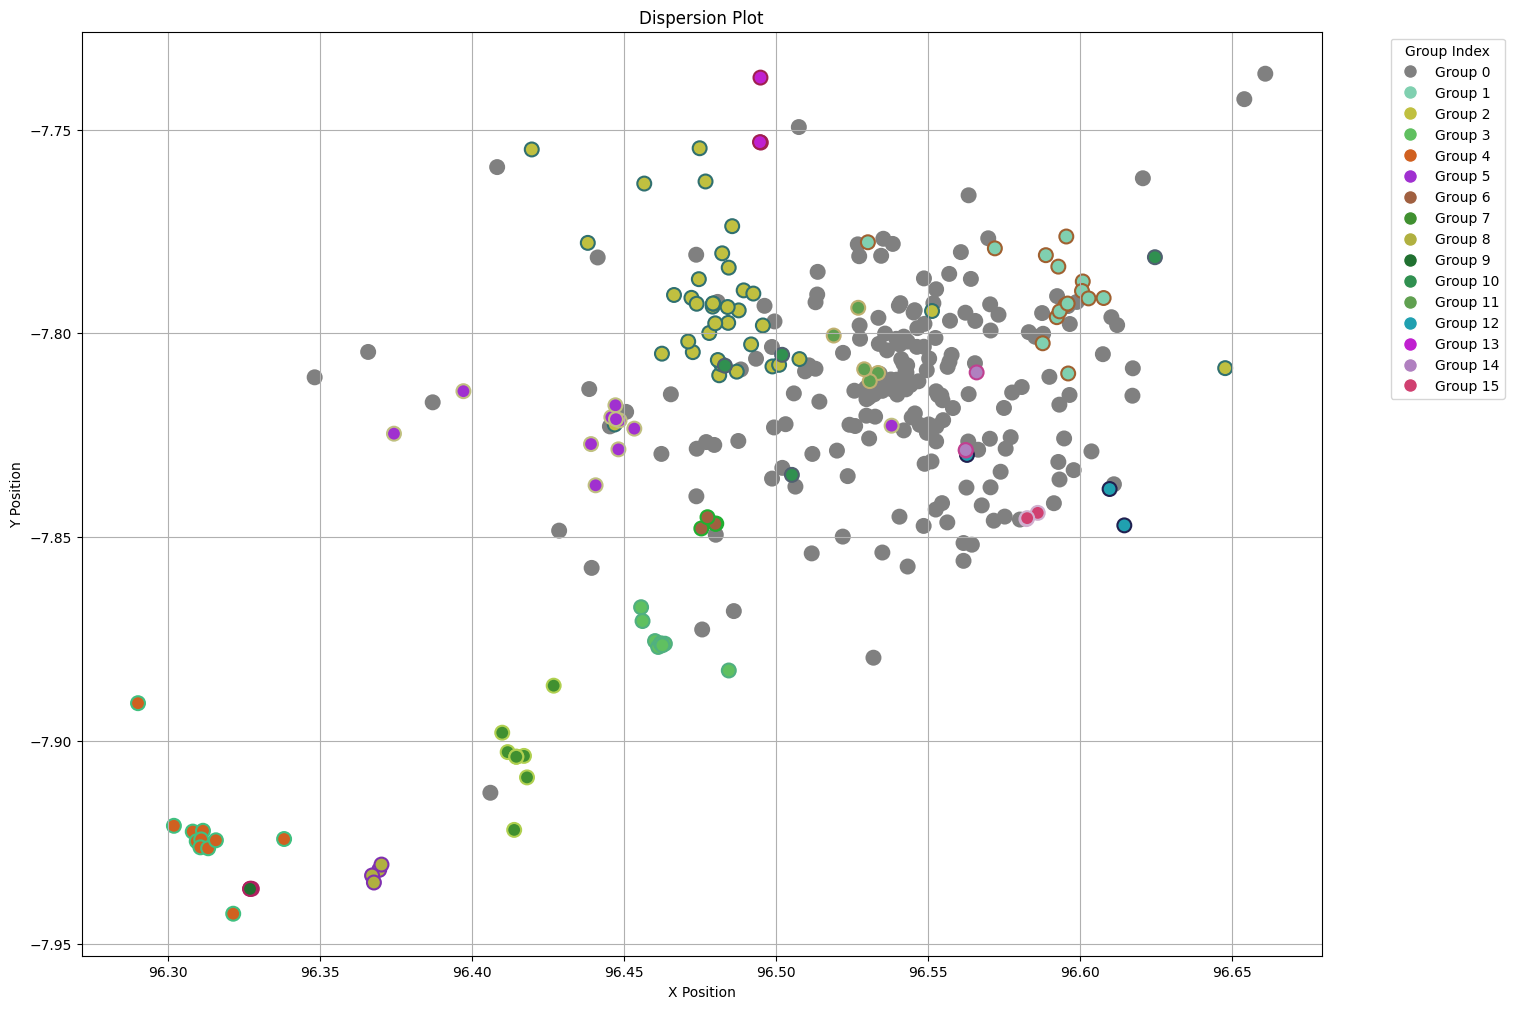

In [19]:
group = np.array(sample.iloc[:, 2].values, dtype=int)

cplt.plot_with_custom_colors(X_data, Y_data, np.ones_like(X_data), group)
plt.show()


Plot DS_test

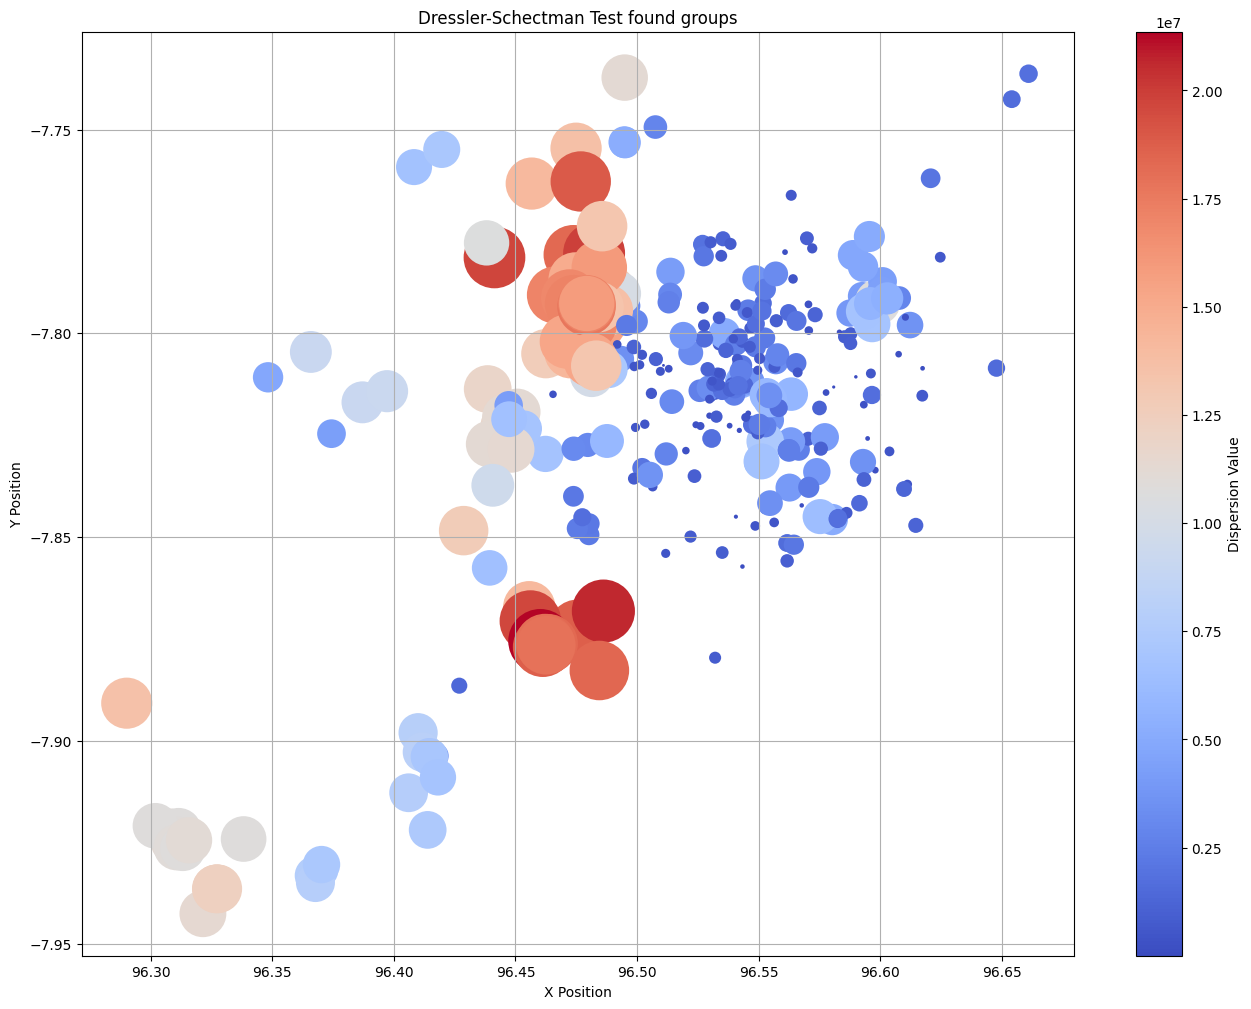

In [14]:
deltas = clustering.run_DS_test(X_data, Y_data, V_data)

cplt.plot_with_gradient(X_data, Y_data, deltas,scale=0.0001, legend='Dressler-Schectman Test found groups')
#plotDS(X_Kpc, Y_Kpc, DS_deltas, scale=0.0001)

Plot DS+

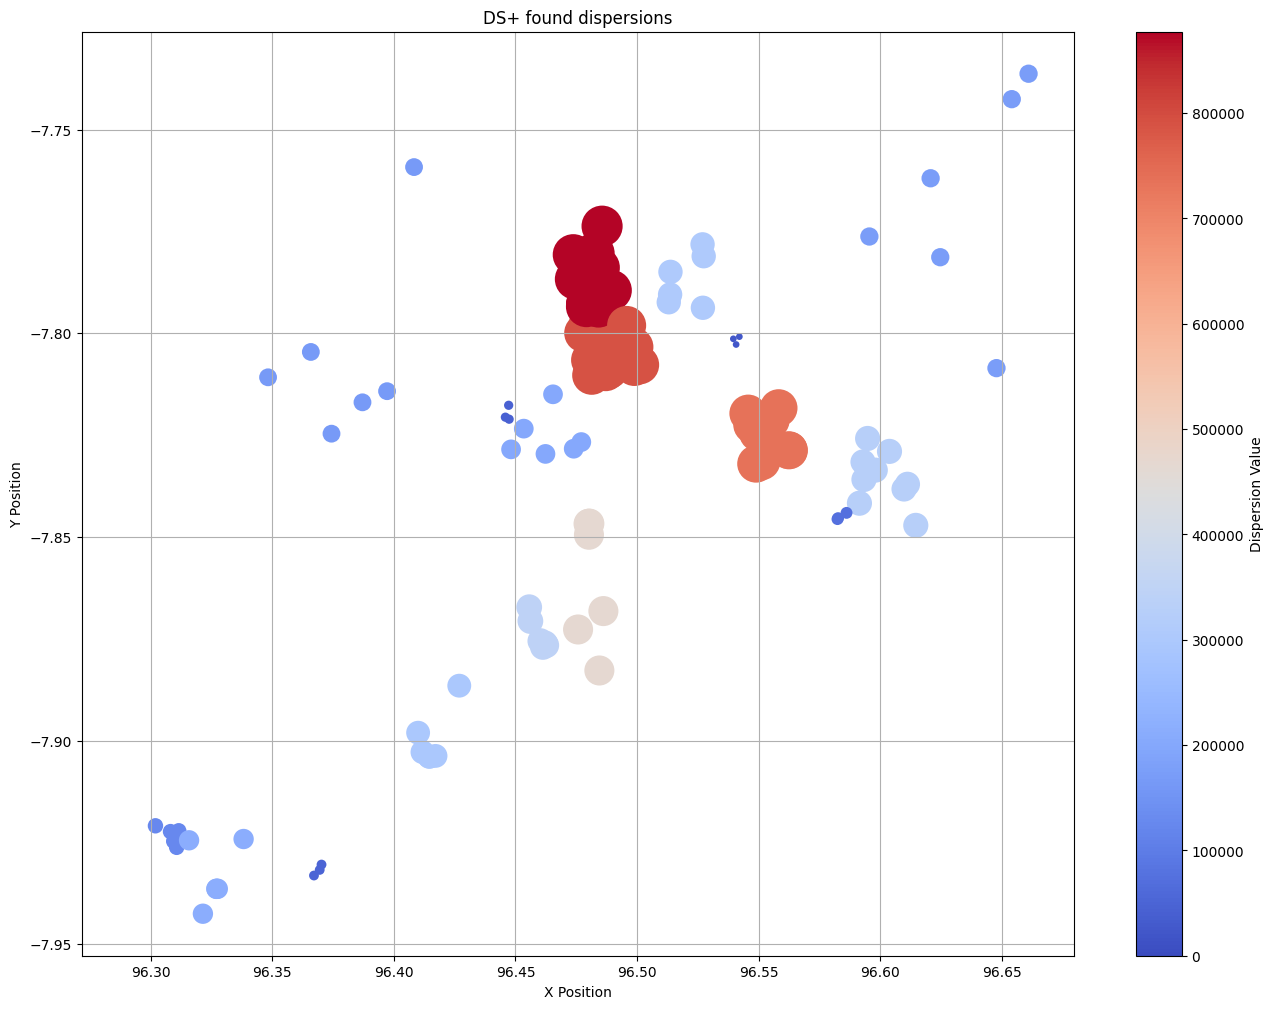

IndexError: arrays used as indices must be of integer (or boolean) type

In [187]:
n_cluster, labels, output = clustering.run_DSP_test(X_Kpc, Y_Kpc, V_data, Z_clus)
V_disp = output[:, 3]

colour_indexes = np.unique(labels, return_inverse=True)[1]

colours = cplt.generate_high_contrast_colors(n_cluster)

cplt.plot_with_gradient(X_data, Y_data, V_disp,scale=0.001, legend='DS+ found dispersions');
cplt.plot_with_custom_colors(X_data, Y_data,np.ones_like(X_data),np.ones_like(X_data), colours, colour_indexes, scale=100, legend='DS+ found groups', edgecolors='none', linewidth=0)
#plotDS(X_Kpc, Y_Kpc, V_disp,scale=100);

Plot GMM

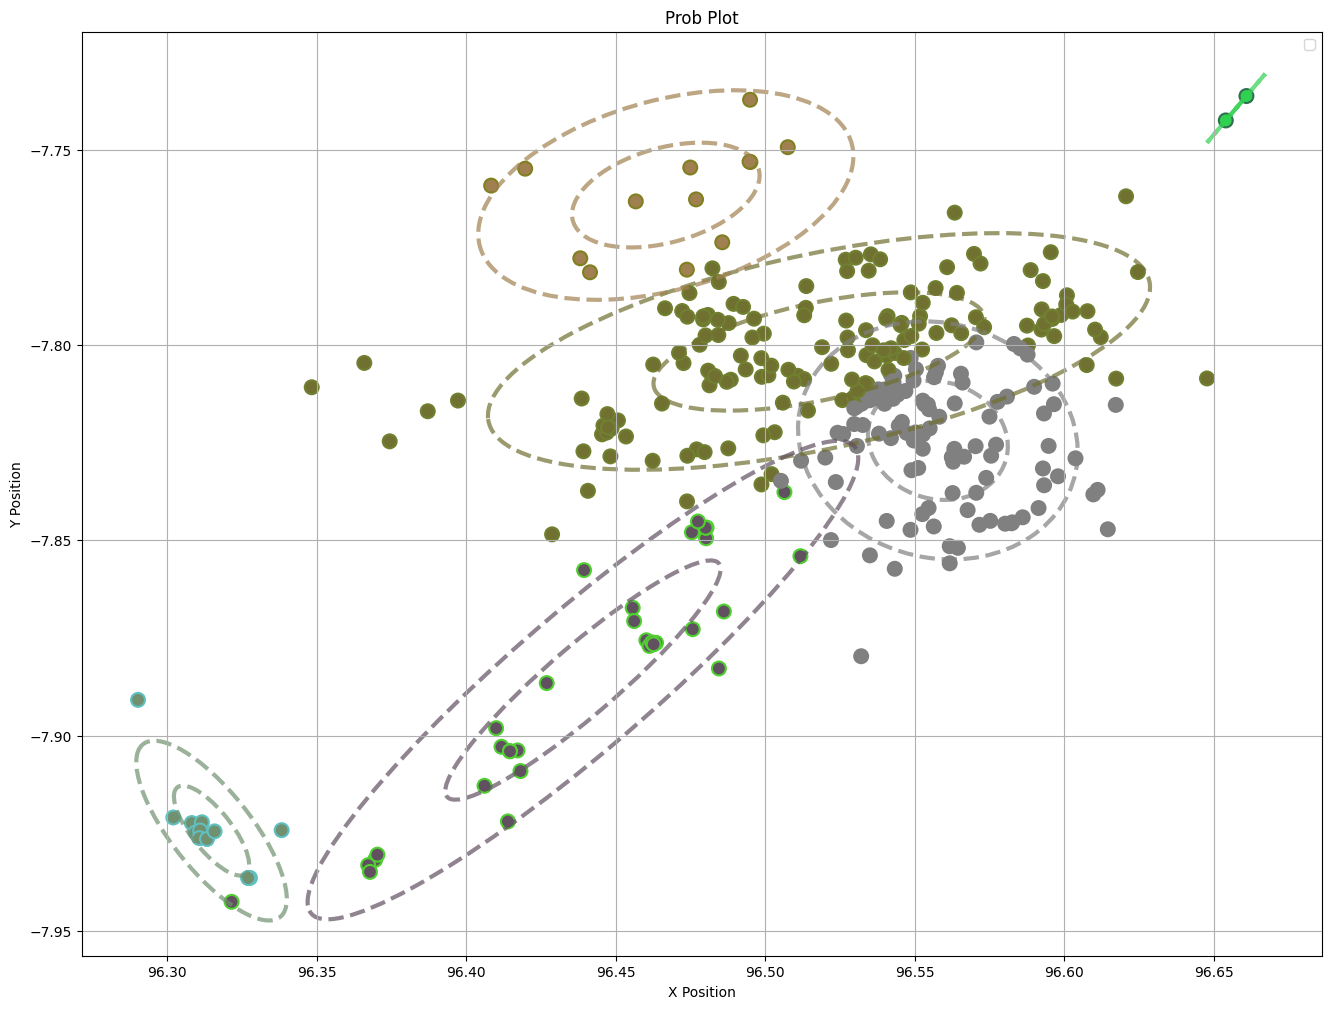

[ 2  2  2  2  2  8  2  3  2  2  2  2  2  2  2  3  2  3  3  8  3  3  7  2
  3  8  2  3  2  3  2  3  3  3  3  7  2  3  2  2  2  2  2  3  2  3  3  2
  3  3  3  2  3  7  2  3  3  7  2  3  3  2  5  3  7  2  2  3  3  2  3  5
  2  3  2  2  3  3  3  3  2  2  3  2  3  3  3  3  2  3  2  3  2  3  2  3
  2  2  3  3  2  3  3  7  2  2  3  2  2  3  3  2  3  3  3  3  3  3  3  3
  3  2  2  2  2  2  3  3  3  2  2  8  3  2  2  2  3  3  3  2  3  2  2  3
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  3  2  2  2  3  3  3  2  3
  3  3  7  2  3  2  3  3  2  3  2  3  3  2  3  2  3  3  2  2  2  2  2  3
  2  3  2  2  3  2  3  3  3  3  3  3  2  3  3  3  3  3  3  3  3  3  3  3
  3  3  8  3  8  8  3  3  8  3  3  3  3  3  3  3  3  3  3  3  3  8  3  3
  3  3  3  3  3  8  3  3  3  7  7  7  7  7  7  7  7 15 15 15  7 15 15 15
 15 15 15 15  3  2  3  3  3  3  3  3  3  3  3  7  7  7  7  7  7  7  7  7
  7  7  7  7  7  7  7 15 15 15  3  2  3  3  3  3  3  3  3  2  2  2  8  8
  8  2  2  2  2  2  2]


In [204]:
labels, prob, clusterer = clustering.run_GMM(data, params)

colour_indexes = np.unique(labels, return_inverse=True)[1]

colours = cplt.generate_high_contrast_colors(len(colour_indexes))
edge_colours = cplt.generate_high_contrast_colors(len(colour_indexes))


cplt.plot_prob_with_data_and_custom_colors(X_data, Y_data, np.ones_like(X_data), colours, colour_indexes, labels, np.max(prob, axis = 1), legend="Prob Plot", edge_color_array=edge_colours, sigma_levels = 2)
plt.show()

print(labels)

Metrica de distancia haversin
Metodo para vecinos ball tree

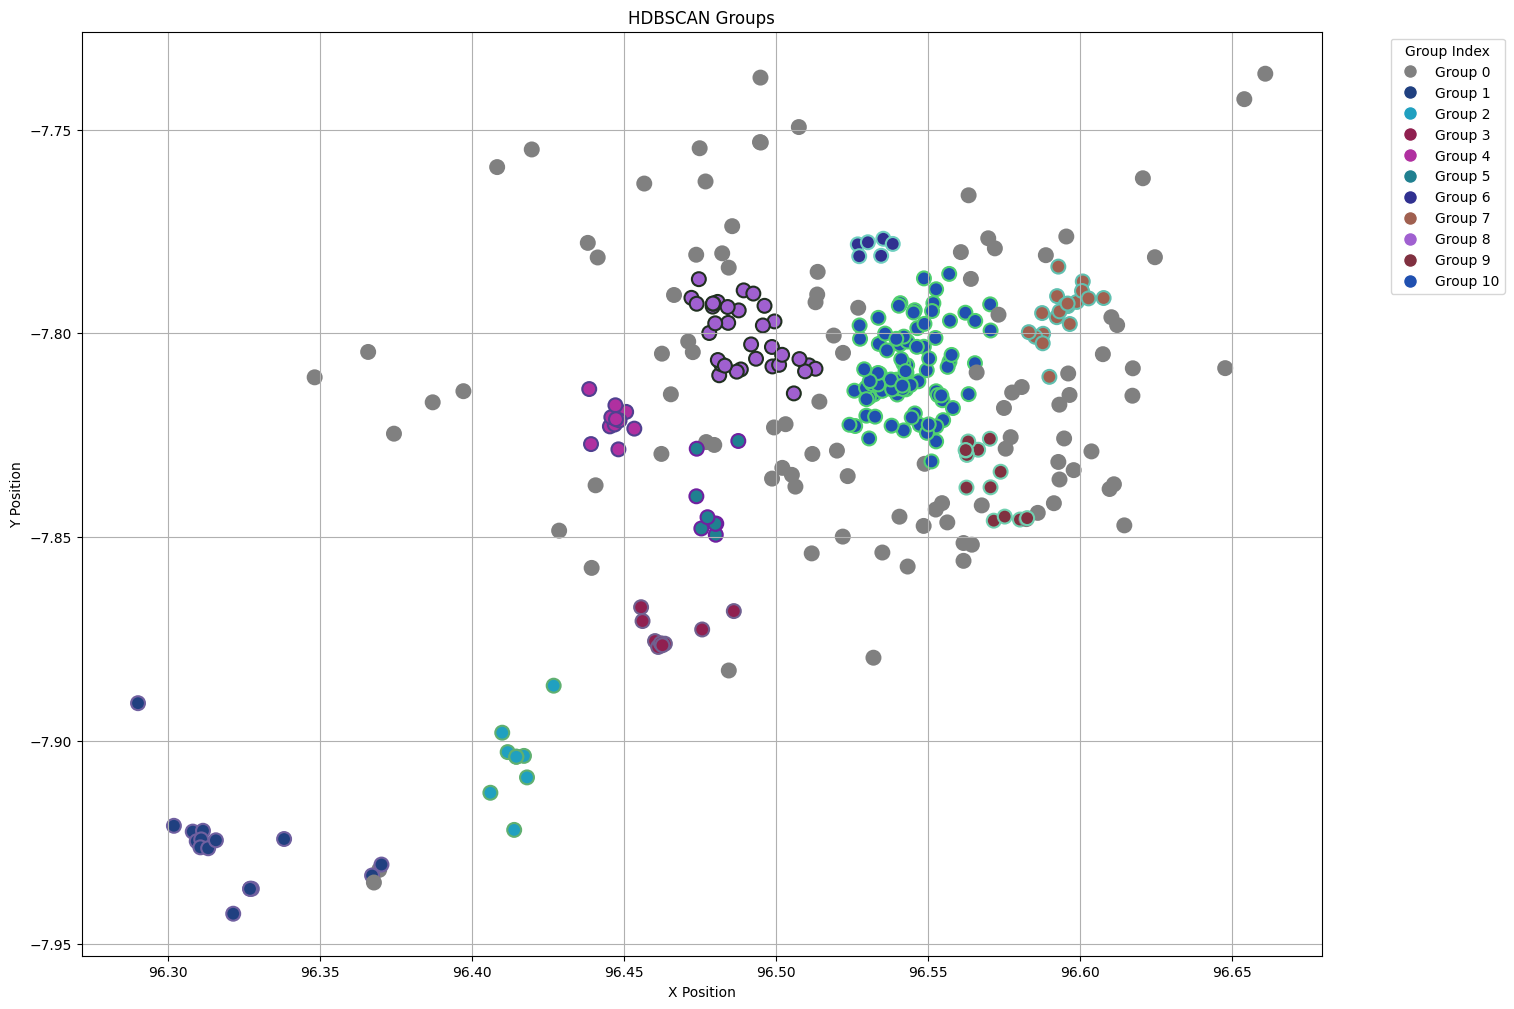

[ 9  9  9  9 -1 -1  8 -1 -1  9  9  9 -1 -1  8  9  8  9  9 -1  7 -1  4  8
 -1 -1 -1  6 -1  9 -1 -1  9  9 -1  2  9 -1  8  9  9  9  9 -1  6  9 -1 -1
  5  3  9  9 -1  1 -1 -1  6  2 -1  7  9  9 -1  6 -1  9 -1 -1  9  9 -1 -1
  9 -1 -1 -1  9 -1 -1  9  9 -1  9 -1  5  9  3  7 -1 -1  8  9  9 -1  9  4
 -1  9  9 -1 -1  7 -1 -1  8  9  9 -1  9  5 -1 -1  7 -1  5  9 -1 -1  9  9
  6  9  9 -1  9  6  5  9  4  6  9 -1 -1 -1  8 -1  9  9  9 -1  9  9  9  9
 -1  9 -1 -1  9  9  9  9  9  9 -1  9  9  9 -1  7  9  9  9  9  4  7  9  9
  7  9 -1  9  7  9  3 -1  9 -1  9  6  9  9  6 -1  7  9 -1  9  8  9 -1 -1
  9  9  9  9  6 -1 -1  6  6  6  6  5  6  6  6 -1 -1  6  6  7  7  7  7  7
  7 -1 -1  7 -1 -1 -1  7 -1  7  3  7  7 -1 -1  7  7  7  7 -1 -1 -1 -1  7
  7  7  9  7  7 -1  7  7  7  2  2  2  2  2  2 -1  2  0  0  0  0  0  0  0
  0  0  0  0  3  9  3  3  3  3 -1  3 -1  3 -1  4  4  4  4  1  1  1  1  1
  1  1  1 -1  0 -1  0  0  0  0  7 -1 -1  7  9  9  9 -1 -1  8 -1 -1 -1 -1
 -1  8  8 -1 -1 -1  8]


In [214]:
labels, prob, clusterer = clustering.run_HDBSCAN(data, params)

colour_indexes = np.unique(labels, return_inverse=True)[1]

colours = cplt.generate_high_contrast_colors(n_cluster)
edge_colours = cplt.generate_high_contrast_colors(len(colour_indexes))

cplt.plot_with_custom_colors(X_data, Y_data, np.ones_like(X_data), colours, colour_indexes, scale=100, legend='HDBSCAN Groups', edgecolors='none', linewidth=1.5, edge_color_array=edge_colours)
plt.show()


print(labels)

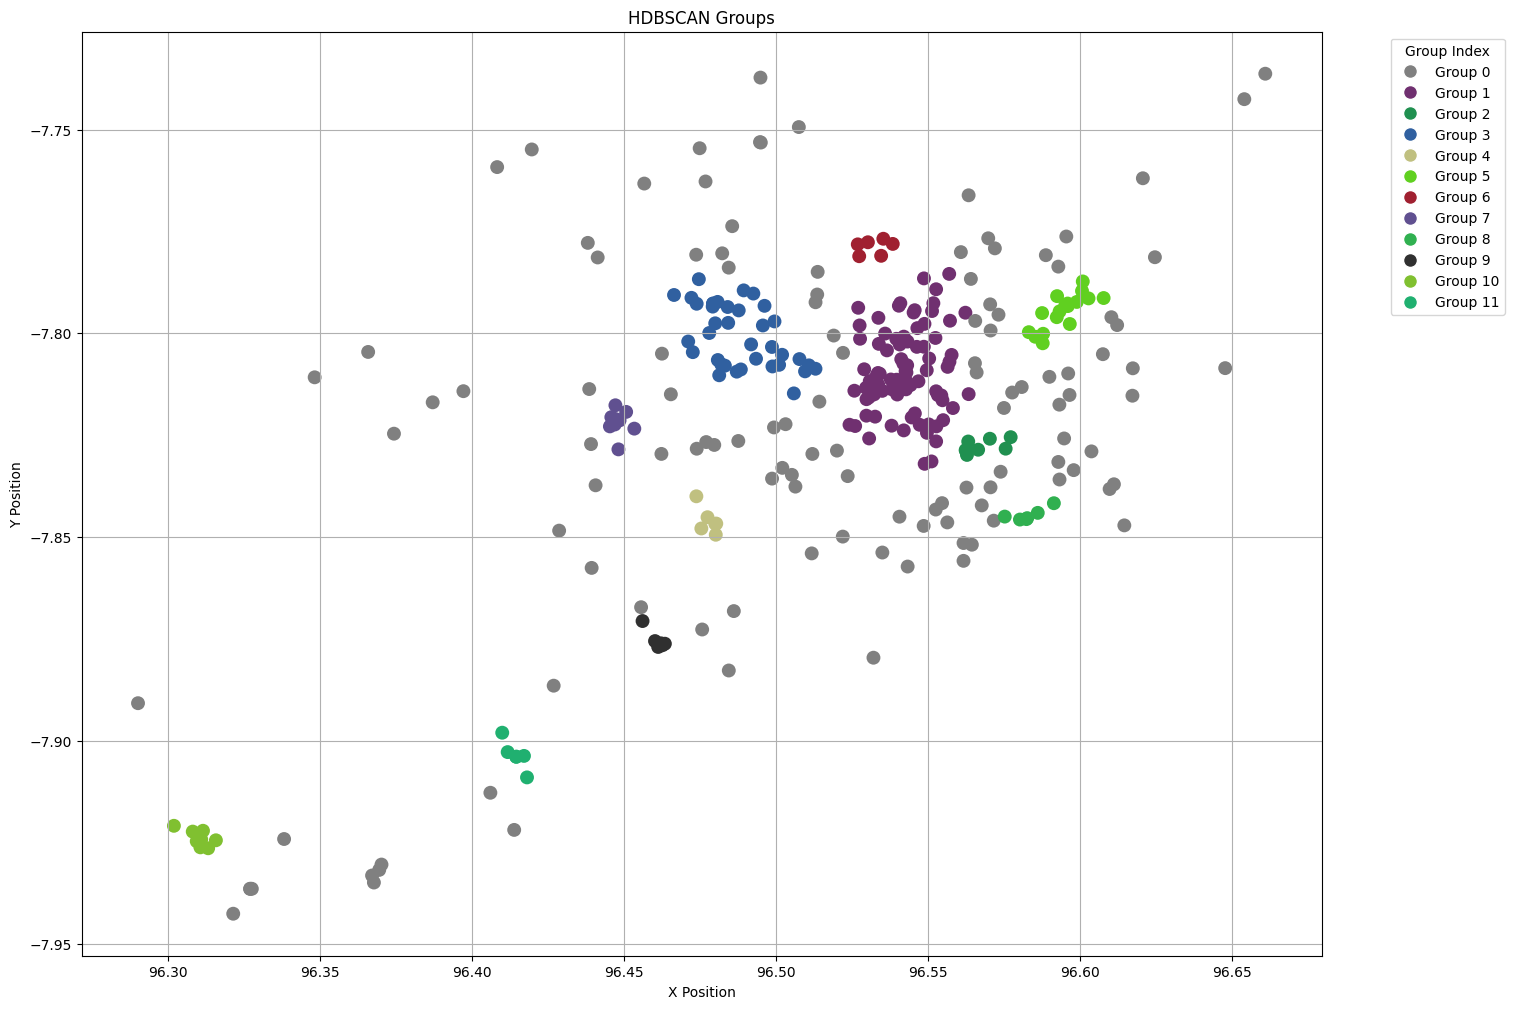

[ 0  0  0  0 -1 -1 -1 -1 -1  0  0  0  0 -1  1  0  1  0  0 -1  2 -1  3  1
 -1 -1 -1  4 -1  0 -1 -1  0  0 -1 -1  0 -1 -1  0  0  0  0 -1  4  0 -1 -1
  5  6  0  0 -1 -1 -1 -1  4 -1  1  2  0  0 -1  4 -1  0 -1 -1 -1  0 -1 -1
  0 -1 -1 -1  0 -1 -1  0  0 -1  0 -1  5  0 -1  2 -1 -1  7  0  0 -1  0  3
 -1  0  0 -1  1  2 -1 -1 -1  0 -1 -1  0  5 -1 -1  2 -1  5  0 -1 -1  0  0
  4  0  0 -1  0 -1  5  0 -1  4  0 -1 -1 -1 -1 -1  0  0  0  7  0  0  0  0
 -1  0 -1 -1  0  0  0 -1  0  0 -1  0  0  0 -1  2  0  0  0  0 -1  2  0  0
  2  0 -1  0  2  0  6 -1  0 -1  0  4  0  0  4 -1  2  0 -1 -1  7  0 -1 -1
  0  0  0  0  4 -1 -1  4  4 -1  4  5  4  4  4 -1 -1  4  4  2  2  2  2  2
  2 -1 -1  2 -1 -1  2  2 -1  2  6  2  2 -1 -1  2  2  2  2  2 -1 -1  2  2
  2  2  0  2  2 -1  2  2  2 -1  8  8  8  8  8 -1  8  9 -1  9 -1  9  9  9
  9 -1  9  9  6  0  6  6 -1  6 -1  6 -1  6 -1  3  3  3  3 -1 -1 10 10 10
 10 10 10 -1 -1 -1 -1 -1 -1 -1  2 -1 -1  2  0  0  0 -1  0  1 -1 -1 -1 -1
 -1  1  1 -1  7  7  7]


In [ ]:

labels, prob, clusterer = clustering.run_DBSCAN(data, params)

colour_indexes = np.unique(labels, return_inverse=True)[1]

colours = cplt.generate_high_contrast_colors(len(colour_indexes))
edge_colours = cplt.generate_high_contrast_colors(len(colour_indexes))

cplt.plot_with_custom_colors(X_data, Y_data, np.ones_like(X_data), colours, colour_indexes, scale=100, legend='DBSCAN Groups', edgecolors='none', linewidth=1.5, edge_color_array=edge_colours)
plt.show()

print(labels)

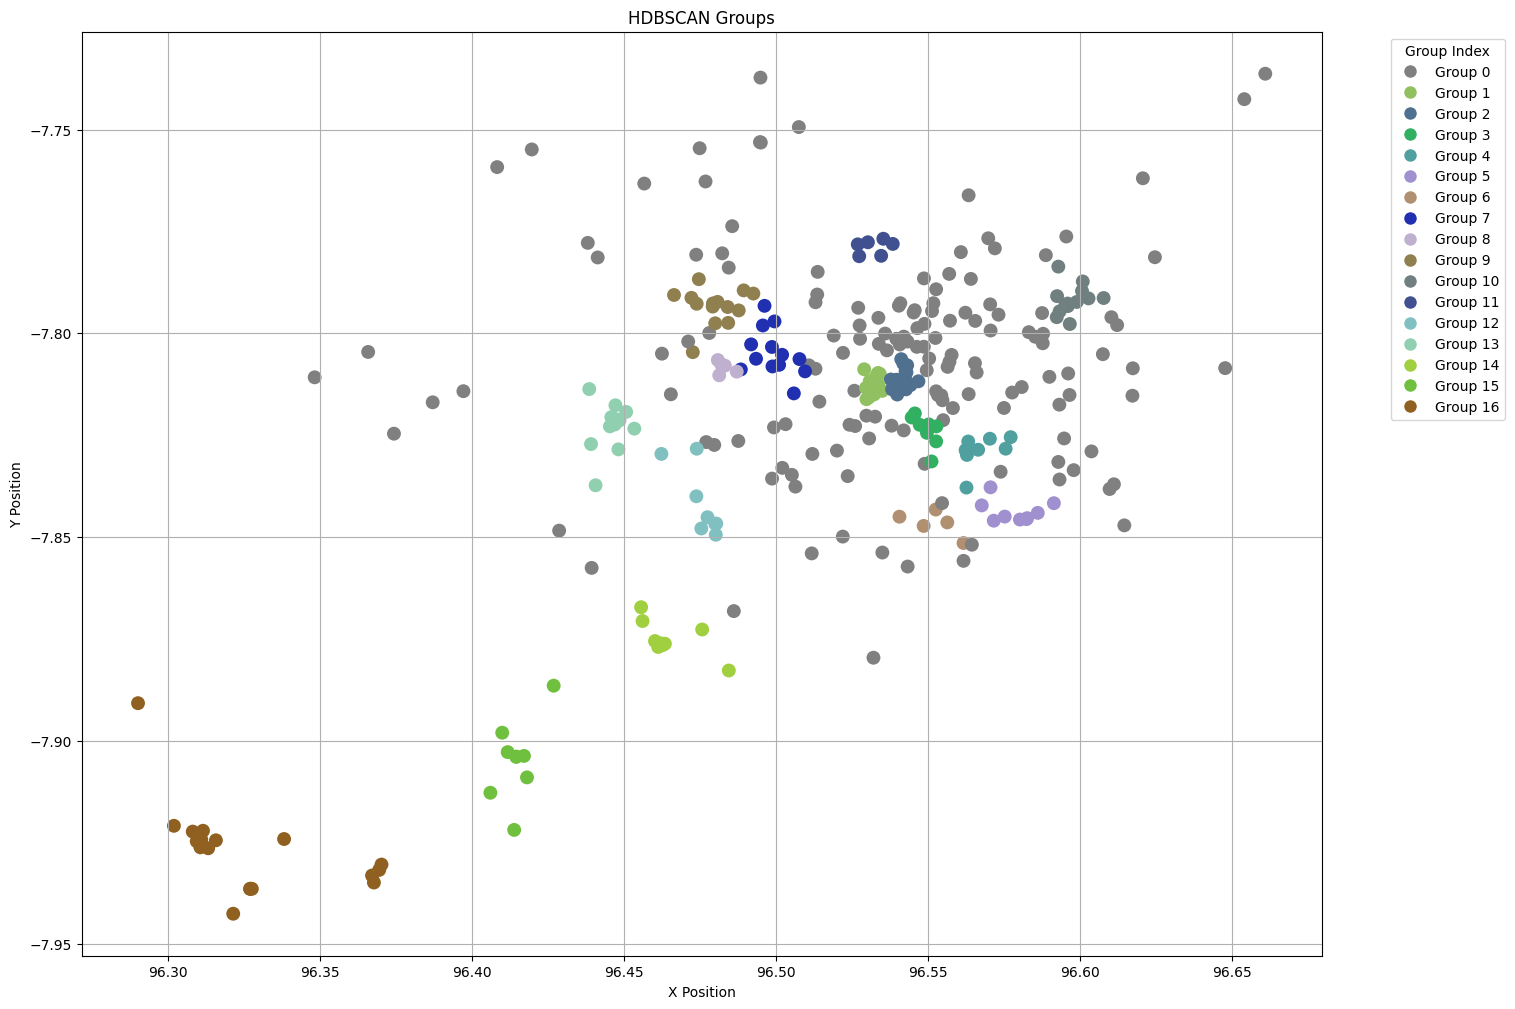

[ 0  1 -1 -1 -1 -1  4 -1  4  1  1  1 -1  5  3 -1  3 -1 -1 -1  8 -1 11  3
 -1 -1 -1 -1  5 -1 -1 11 -1 -1 -1 13  1 -1 -1  1  1  1  1 -1 -1 -1 -1 -1
 10 12 -1 -1 -1 14 -1 -1  9 -1  3 -1 -1  1 -1  9 -1 -1 -1 -1 -1  2 -1 -1
  1 -1  5 -1 -1 -1 -1  0  1 -1  1  5 10 -1 12 -1 -1 -1  4 -1 -1 -1  2 11
 -1  2 -1 -1  3  6 -1 -1  3 -1 -1 -1  1 10 -1 -1  6 -1 10 -1 -1 -1 -1  0
  9  0 -1 -1 -1 -1 10 -1 11 -1  2 -1 -1  5  4 -1  0 -1 -1  4 -1 -1 -1 -1
 -1  1 -1 -1  1  0 -1 -1  1 -1 -1 -1 -1 -1 -1  6  1  2 -1 -1 -1  6  2 -1
  6  0 -1  1  6 -1 12 -1  2 -1 -1 -1 -1  1  9 -1  6 -1 -1 -1  4 -1 -1 -1
  0 -1  0  2  9 -1 -1  9  9  9  9 10 -1  9  9 -1 -1  9  9  6  6  8  6  8
 -1 -1 -1  7 -1 -1  8  8 -1  8 12  8  8 -1 -1  6  8  7  8  8 -1 -1 -1  8
  8  8 -1  7  7 -1  8  8  6 13 13 13 13 13 13 13 13 15 15 15 15 15 15 15
 15 15 15 15 12 -1 12 12 12 12 -1 12 12 12 -1 11 11 11 11 14 14 14 14 14
 14 14 14 15 15 15 15 15 15 15  7 -1 -1  6  0  0  0 -1 -1  3 -1 -1 -1 -1
 -1  3  3 -1  4  4  4]


In [ ]:
labels, prob, clusterer = clustering.run_OPTICS(data, params)

colour_indexes = np.unique(labels, return_inverse=True)[1]

colours = cplt.generate_high_contrast_colors(len(colour_indexes))
edge_colours = cplt.generate_high_contrast_colors(len(colour_indexes))

cplt.plot_with_custom_colors(X_data, Y_data, np.ones_like(X_data), colours, colour_indexes, scale=100, legend='OPTICS Groups', edgecolors='none', linewidth=1.5, edge_color_array=edge_colours)
plt.show()

print(labels)

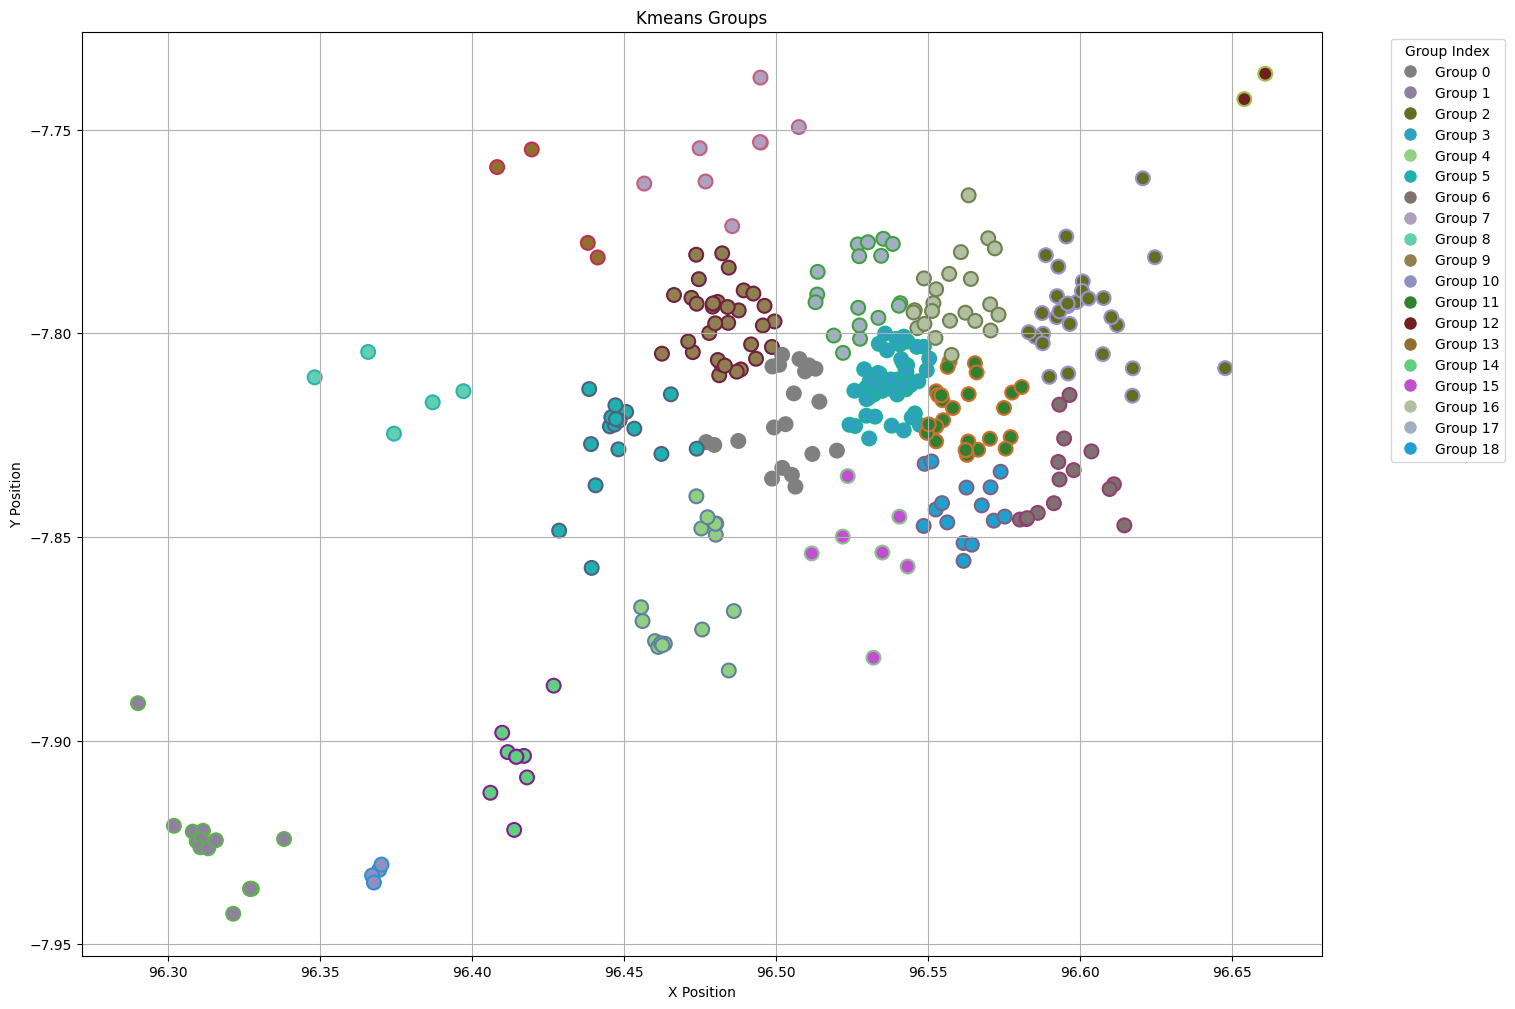

[ 3  3  3 11 15  7 18  0 18  3  3  3 18 18 11 16 11  3 16  9  9 16  4 11
  2 13  6  2 18  3  6  5  3 16 16  4  3 16 18  3  3  3  3  0  2 16  5  6
 17  5 17 11 17 14  2  8  2  4 11  0  3  3 12  2  0  3 11  2 16  3  0 12
  3  8 18 15 16  5  0  3  3  6  3 18 17 17  5  0  6  2  6 16 11  8 11  4
 11  3 16 17 11  0  0  5 18 11 16  6  3 17 16  6  9  0 17 16  2 17 17  3
  2  3  3  0 11  2 17  3  5  2 11 13 16 15 18 15  3 16  3  6 16  3  3 16
  0  3 18 18  3  3 11 16  3  3 15 16  3 11 15  9  3  3  3  3  0  0 11 17
  9  3 15  3  9  3  5  0 11  2 11  2  3  3  2  6  9  3 11 11 18 11 18 17
  3 17  3 18  2  2 16  2  2  2  2 17  2  2  2  2  2  2  2  0  0  9  0  9
  9  9  7  9 13  7  9  9 13  9  5  9  9  9  9  9  9  9  9  9  2  7  9  9
  9  9 16  9  9  7  9  9  9  4  4  4  4  4  4  4  4  1  1  1  1  1  1  1
  1  1  1  1  5  3  5  5  5  5  8  5  5  5  8  4  4  4  4 14 14 14 14 14
 14 14 14 10 10 10 10  1  1  1  9  0  2  0  3  3  3 17 17 11  6  6  7  7
  7 11 11 11  6  6  6]


In [215]:
labels, prob, clusterer = clustering.run_Kmeans(data, params)

colour_indexes = np.unique(labels, return_inverse=True)[1]

colours = cplt.generate_high_contrast_colors(len(colour_indexes))
edge_colours = cplt.generate_high_contrast_colors(len(colour_indexes))

cplt.plot_with_custom_colors(X_data, Y_data, np.ones_like(X_data), colours, colour_indexes, scale=100, legend='Kmeans Groups', edgecolors='none', linewidth=1.5, edge_color_array=edge_colours)
plt.show()

print(labels)

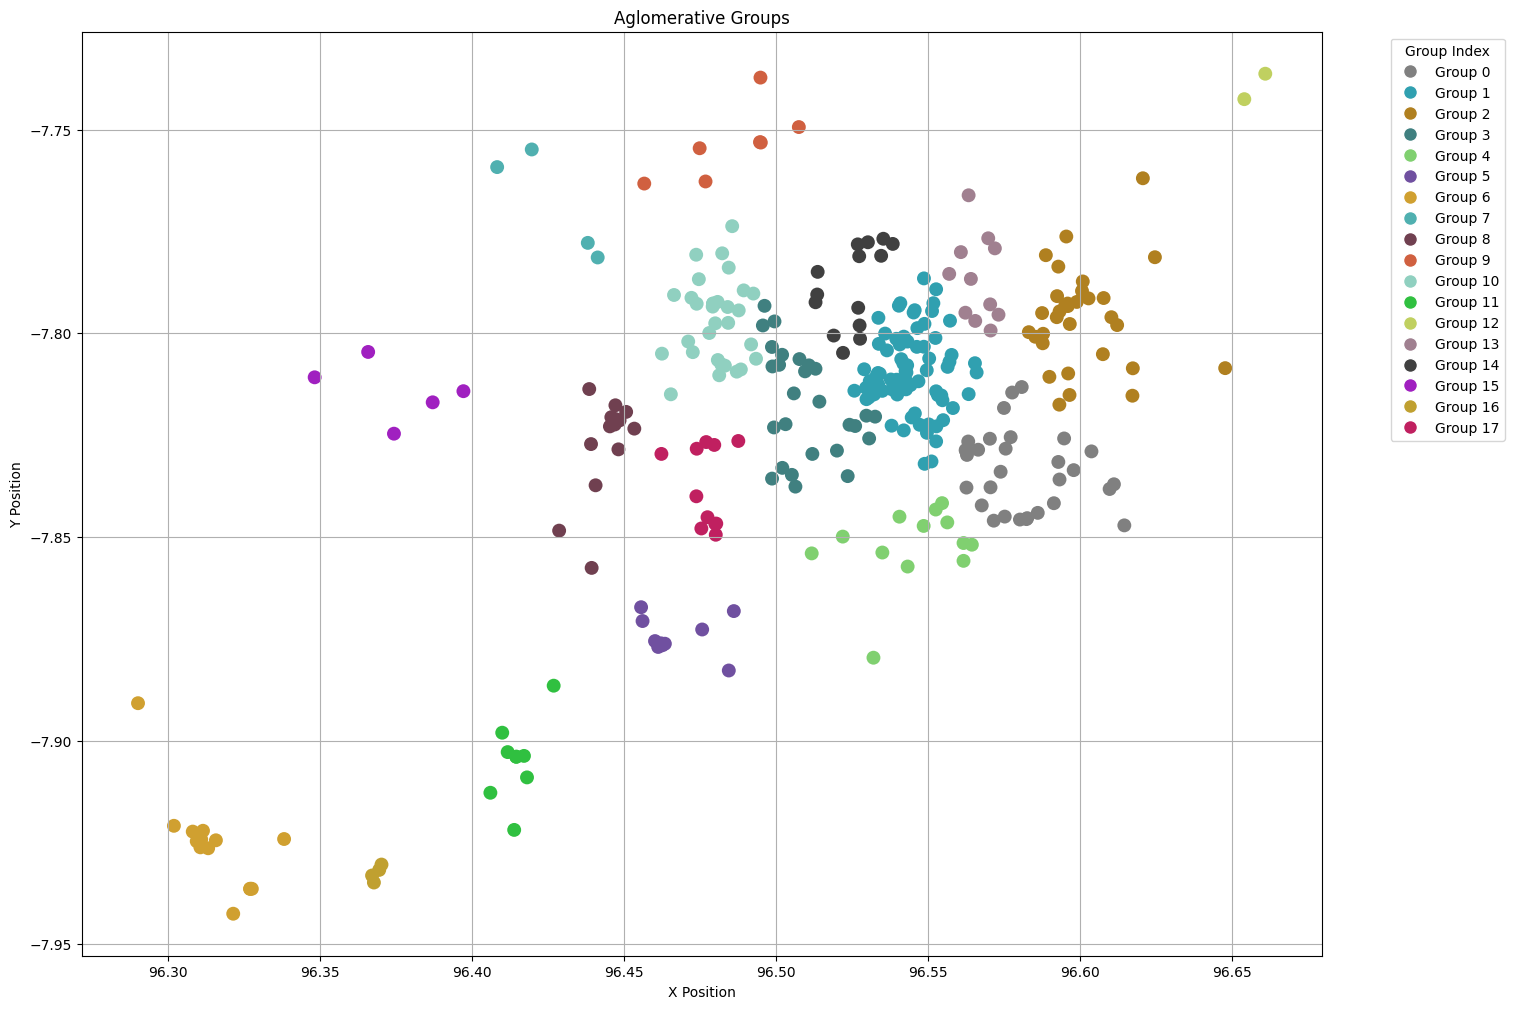

[ 1  1  3  1  4  9  0  3  0  1  1  1  1  4  0 13  0  1  1 10 10 13 17  0
  2  7  0  2  4  1  0 17  1  1 13  5  1 13  0  1  1  1  1 17  2  1 10  0
 14  8  1  1 14 11  2 15  2  5  0  3  1  1 12  2  3  1  0  2 13  1 17 12
  1 15  4  4  1  8  3  1  1  0  1  4 14  1  8  3  0  2  0  1  1 15  1 17
  0  1  1 14  0  3  3  8  0  1 13  2  1 14 13  0  3  3 14  1  2 14 14  1
  2  1  3  3  1  2 14  1 17  2  1  7 13  4  0  4  1  1  1  0 13  3  3  1
  3  1  4  4  1  1  1 13  1  1  3  1  1  1  4 10  1  1  1  1 17  3  1 14
  3  1  4  1 10  3  8  3  1  2  1  2  1  1  2  2  3  1  0  1  0  1  4 14
  1  1  1  1  2  2 13  2  2  2  2 14  2  2  2  2  2  2  2  3  3 10  3 10
 10 10  9 10  7  9 10 10  7 10  8 10 10 10 10 10 10 10 10 10  2  9 10 10
 10 10  1 10 10 10 10 10  3  5  5  5  5  5  5  5  5  6  6  6  6  6  6  6
  6  6  6  6  8  1  8  8  8  8 15  8  8  8 15 17 17 17 17 11 11 11 11 11
 11 11 11 16 16 16 16  6  6  6 10  3  2  3  1  1  1 14 14  0  0  0  9  9
  9  0  0  1  0  0  0]


In [ ]:
labels, prob, clusterer = clustering.run_Aglomerative_Clustering(data, params)

colour_indexes = np.unique(labels, return_inverse=True)[1]

colours = cplt.generate_high_contrast_colors(len(colour_indexes))
edge_colours = cplt.generate_high_contrast_colors(len(colour_indexes))

cplt.plot_with_custom_colors(X_data, Y_data, np.ones_like(X_data), colours, colour_indexes, scale=100, legend='Aglomerative Groups', edgecolors='none', linewidth=1.5, edge_color_array=edge_colours)
plt.show()

print(labels)

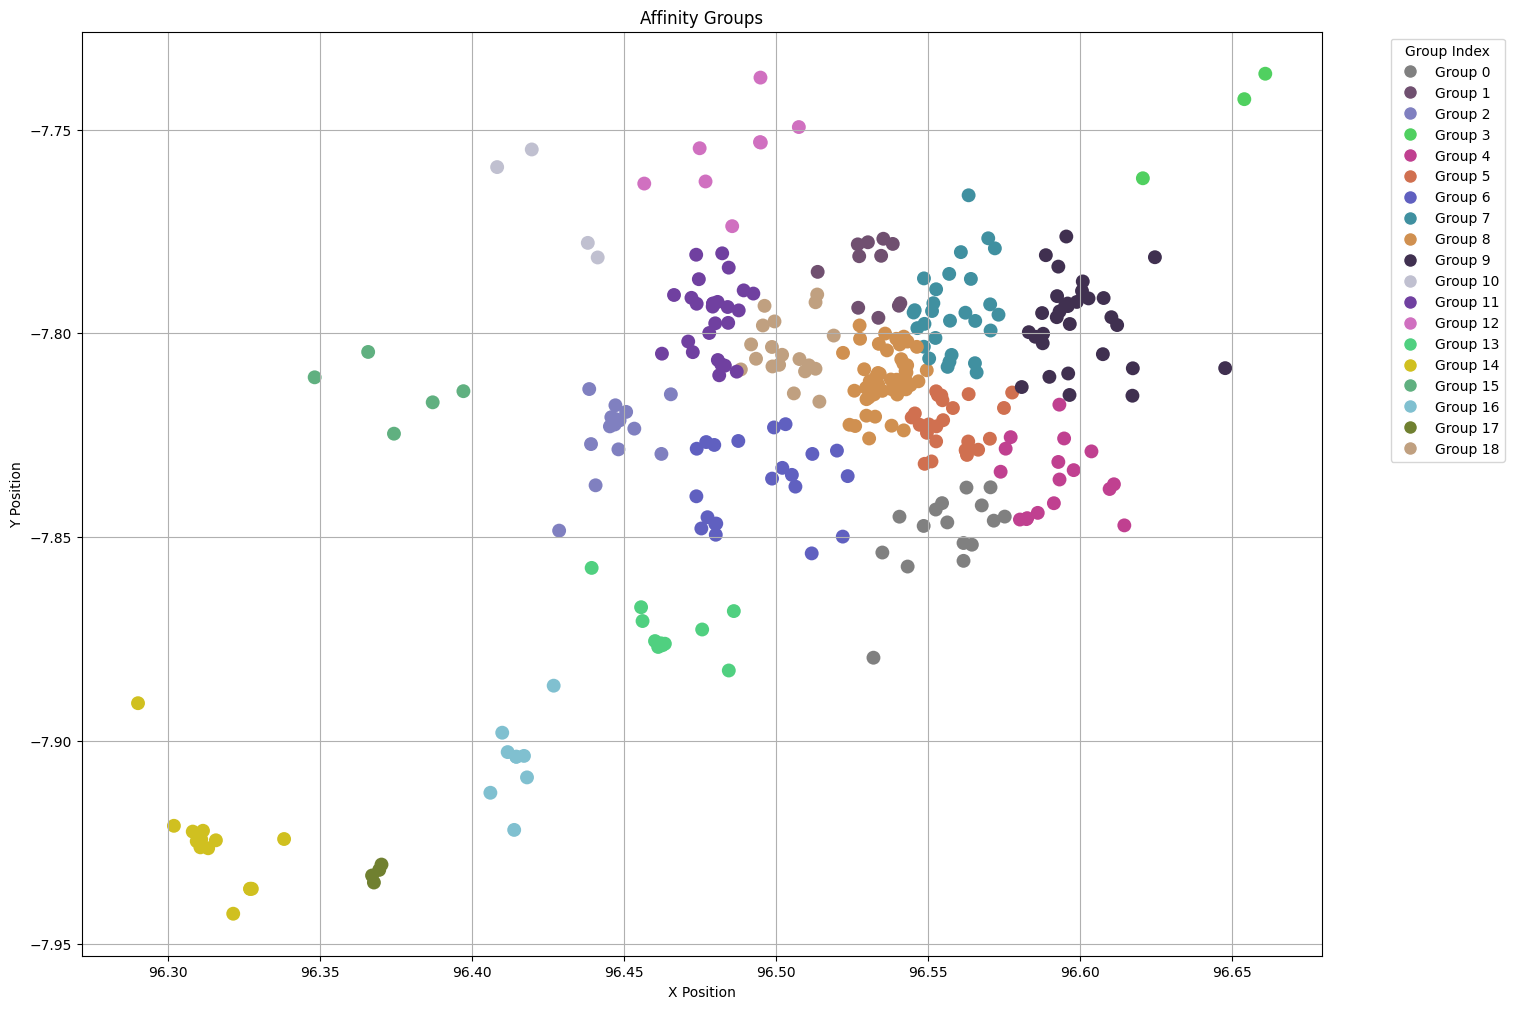

[ 8  8  8  7  0 12  0  6  0  8  8  8  5  0  5  7  5  8  7 11 11  7  6  5
  9 10  4  9  0  8  4  2  8  7  7 13  8  7  4  8  8  8  8  6  9  7  2  4
  1  2  1  5  1 16  9 15  9 13  4 18  8  8  3  9  6  8  5  9  7  5  6  3
  8 15  0  0  7  2  6  8  8  4  8  0  1  1  2 18  4  3  4  7  5 15  5  6
  5  5  7  8  4 18  6 13  0  5  7  4  8  1  7  4 18 18  1  7  9 18  8  8
  9  8  8  6  7  9  1  8  6  9  5 10  7  0  0  6  8  7  8  4  7  8  8  7
  6  8  0  0  8  8  5  7  8  7  6  7  7  5  0 18  8  5  8  8  6 18  5  8
 18  8  6  8 18  8  2  6  5  9  5  9  8  8  9  9 18  8  9  7  0  5  0 18
  8  1  8  5  9  9  7  9  9  9  9  1  9  9  9  9  9  9  9 18 18 11 18 11
 11 11 12 11 10 12 11 11 10 11  2 11 11 11 11 18 11 11 11 11  9 12 11 11
 11 11  7 11 11 12 11 11 18 13 13 13 13 13 13 13 13 14 14 14 14 14 14 14
 14 14 14 14  2  8  2  2  2  2 15  2  2  2 15  6  6  6  6 16 16 16 16 16
 16 16 16 17 17 17 17 14 14 14 11  6  9 18  8  8  8 18  1  5  4  4 12 12
 12  5  5  7  4  4  4]


In [ ]:
labels, prob, clusterer = clustering.run_Affinity_Propagation(data, params)

colour_indexes = np.unique(labels, return_inverse=True)[1]

colours = cplt.generate_high_contrast_colors(len(colour_indexes))
edge_colours = cplt.generate_high_contrast_colors(len(colour_indexes))

cplt.plot_with_custom_colors(X_data, Y_data, np.ones_like(X_data), colours, colour_indexes, scale=100, legend='Affinity Groups', edgecolors='none', linewidth=1.5, edge_color_array=edge_colours)
plt.show()

print(labels)

Metodos

K-means
Aglomerative clustering
Affinity propagation
BIRCH

GMM

DBSCAN
HDBSCAN
OPTICS


Tests

Comparar Prbabilidad 2D vs 3D
Cambiar parametros y metricas 
Agregar perturbaciones a los datos (MTC simulación)
Manejar ruido -> galaxias del halo principal, galaxias de fondo


Metodos Adicionales

Self organizing maps

Test adicionales

Combinar tecnicas

Kernel Density Estimation

(<Figure size 1600x1200 with 1 Axes>,
 <Axes: title={'center': 'Orignial Groups'}, xlabel='X Position', ylabel='Y Position'>)

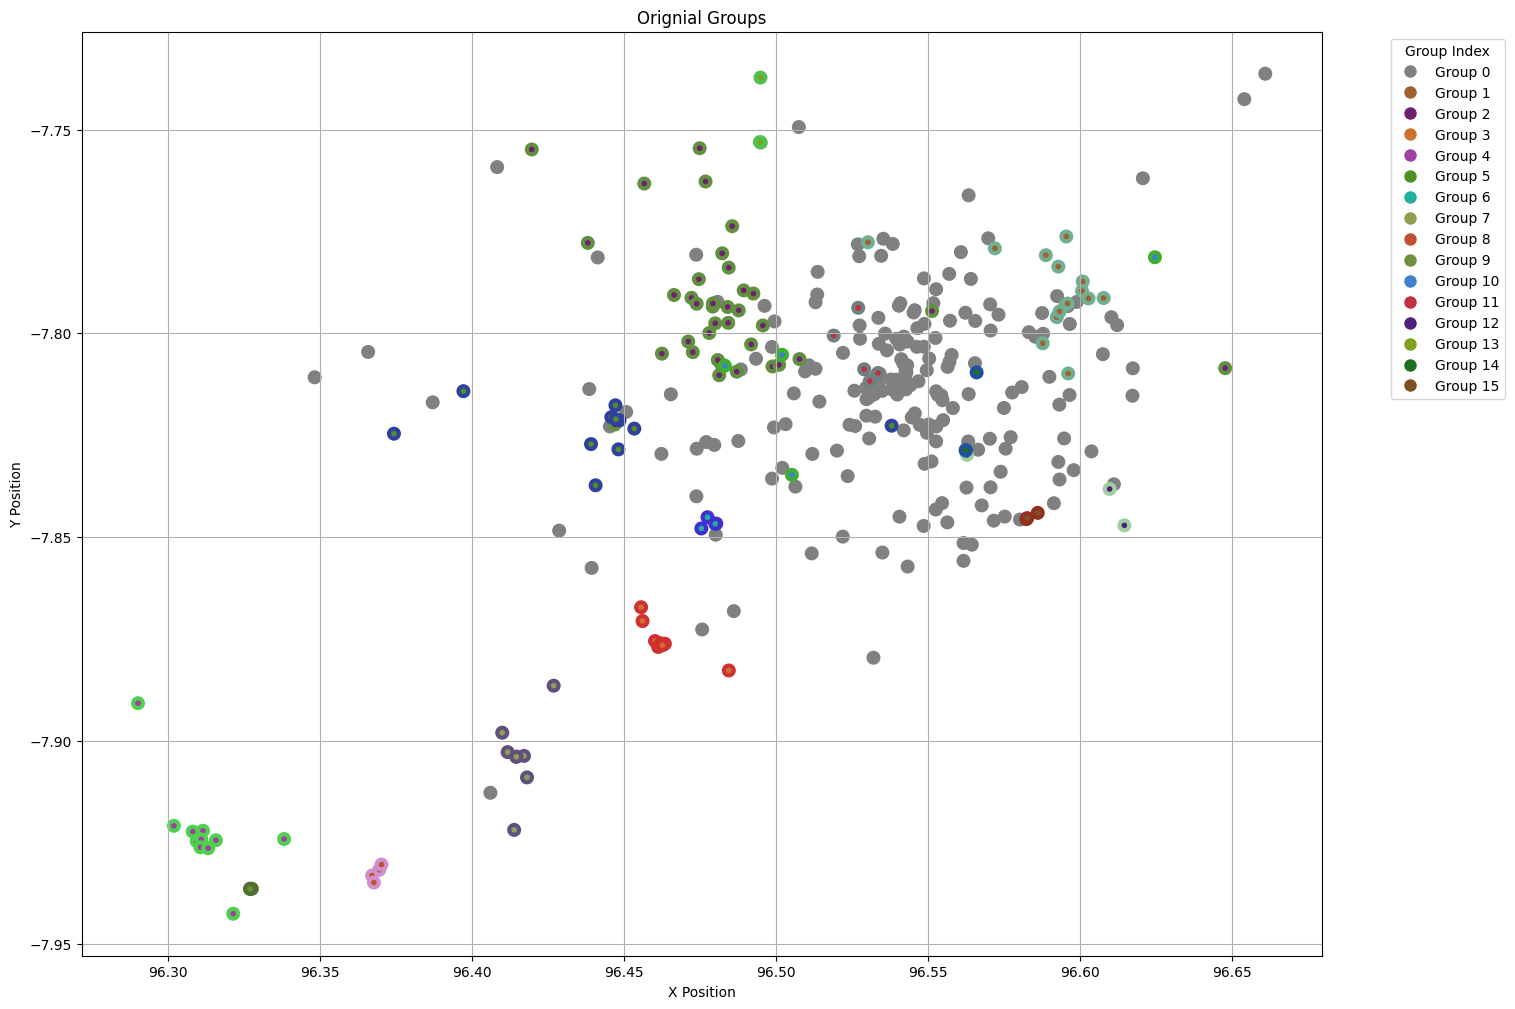

In [33]:
group = np.array(sample.iloc[:, 2].values, dtype=int)


cplt.plot_with_custom_colors(X_data, Y_data, np.ones_like(X_data), group, scale=50, legend='Orignial Groups', linewidth=3)
#plotDS(X_Kpc,Y_Kpc,group+1,scale=10)

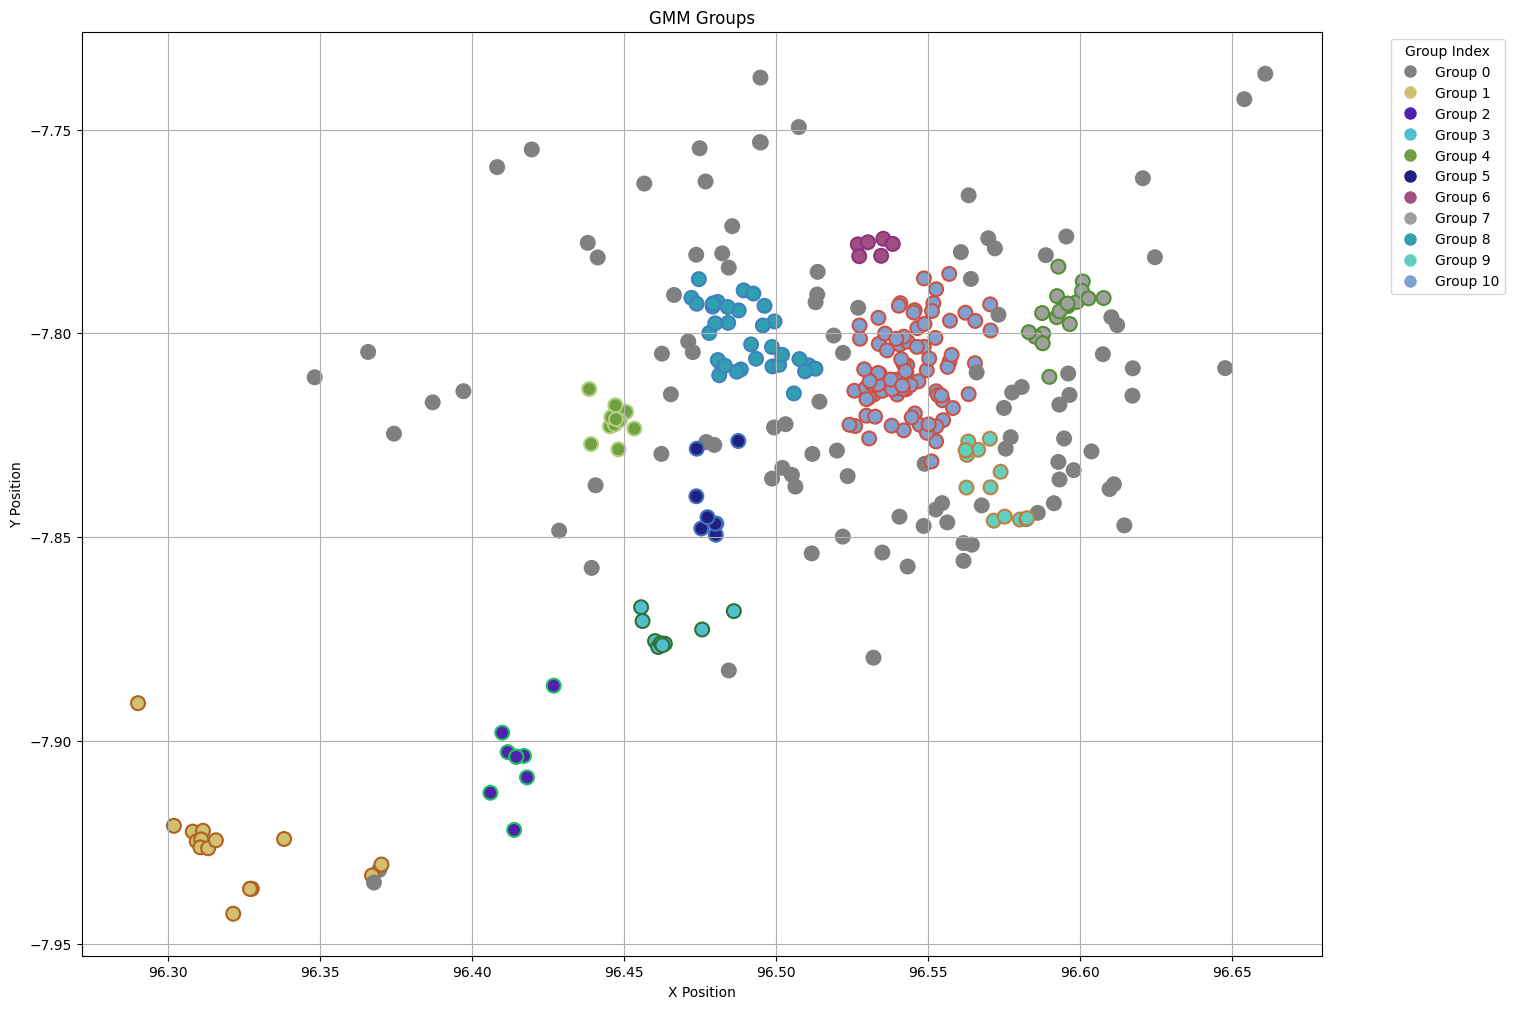

In [23]:
labels, prob, clusterer = clustering.run_HDBSCAN(data, params)

#cplt.plot_with_custom_colors(X_data, Y_data, np.ones_like(X_data), colors, colour_indexes, scale=100, legend='Orignial Groups', edgecolors='none', linewidth=0)
cplt.plot_with_custom_colors(X_data, Y_data, np.ones_like(X_data), labels, scale=100, legend='GMM Groups', linewidth=1.5)
plt.show()


In [58]:

lax_labels = np.where(labels >= 0, 1, -1)

lax_original_labels = np.where(group >= 0, 1, -1)

purity = cmetrics.purity_score(group, labels)
completitud = recall_score(lax_original_labels, lax_labels, average='macro')
f1_score = cmetrics.get_f1_score(completitud, purity)
rand_index = adjusted_rand_score(lax_original_labels, lax_labels)

print(f"Completitud: {completitud}")
print(f"Purity: {purity}")
print(f"F1_score: {f1_score}")
print(f"Rand_index: {rand_index}")

Completitud: 0.5311929649908744
Purity: 0.7429467084639498
F1_score: 0.6194737878761593
Rand_index: -0.008776194729479457


In [59]:
tp, fp, tn, fn, total = cmetrics.calculate_pairwise_metrics(group, labels)
print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"TN: {tn}")
print(f"FN: {fn}")
print(f"Total:  {total}")

purity = cmetrics.get_purity(tp, (tp + fp))
completitud = cmetrics.get_completitud(tp, (tp + fn))
f1_score = cmetrics.get_f1_score(completitud, purity)
rand_index = cmetrics.get_rand_index(tp,(tp + fp), (tp + fn))


print(f"Completitud: {completitud}")
print(f"Purity: {purity}")
print(f"F1_score: {f1_score}")
print(f"Rand_index: {rand_index}")

AttributeError: module 'clustering_metrics' has no attribute 'calculate_pairwise_metrics'

(<Figure size 1600x1200 with 1 Axes>,
 <Axes: title={'center': 'Comparative Plot'}, xlabel='X Position', ylabel='Y Position'>)

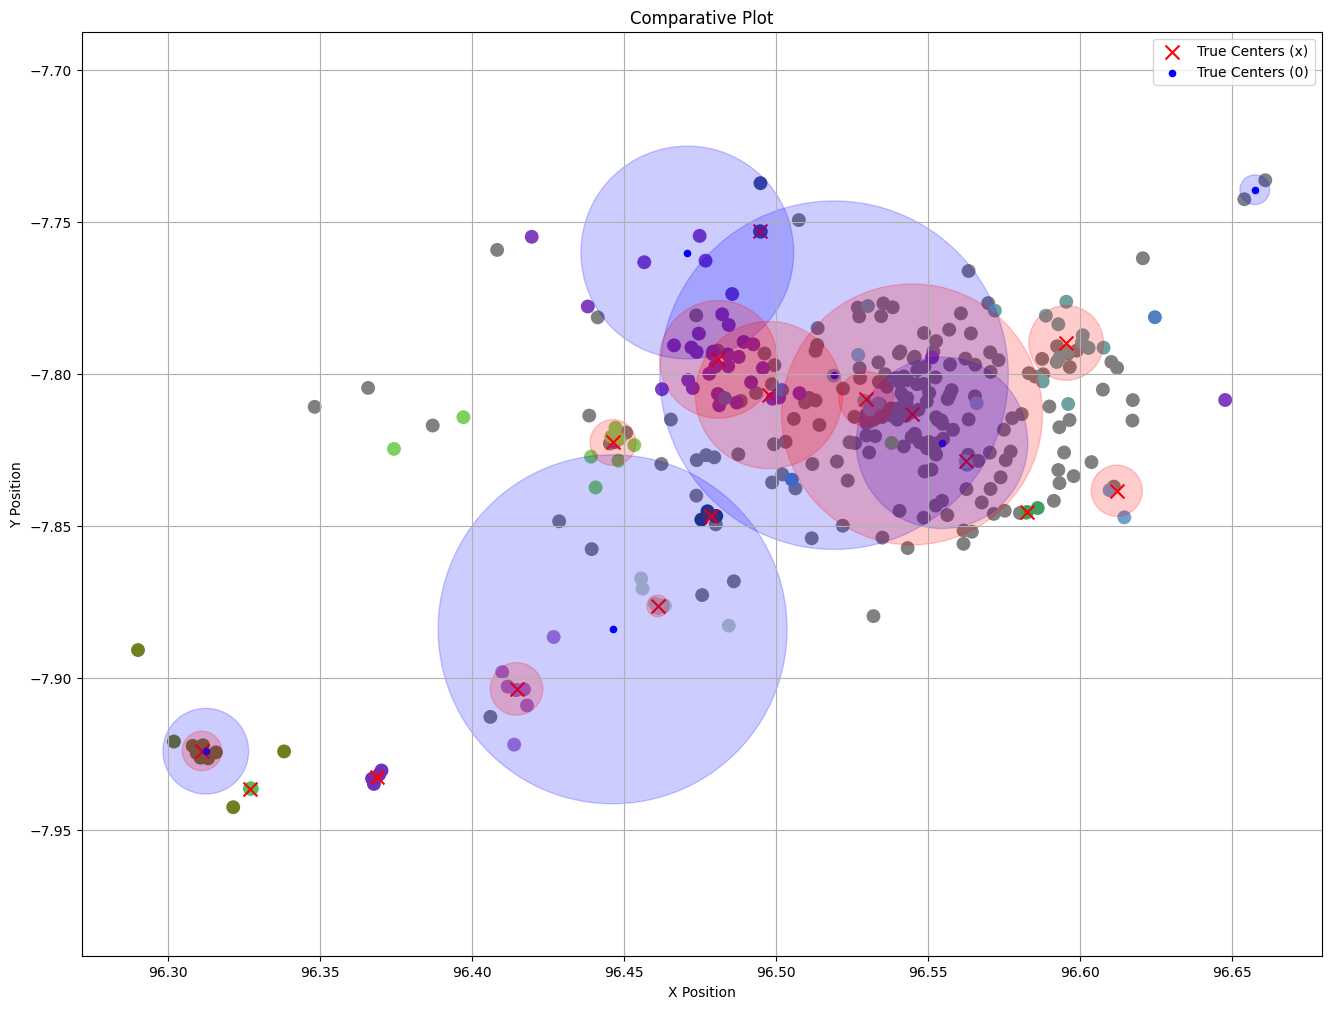

In [17]:
labels, prob, clusterer = clustering.run_GMM(data, params)

cplt.plot_comparative_clusters(X_data, Y_data, group, labels)

In [18]:
true_centers = ctools.get_cluster_center(data, group)
pred_centers = ctools.get_cluster_center(data, labels)

true_mean_centers = mean_column = np.array([cluster['location'] for cluster in true_centers.values()])
pred_mean_centers = mean_column = np.array([cluster['location'] for cluster in pred_centers.values()])

pred_radial_std = np.array([np.linalg.norm(cluster['scale']) for cluster in pred_centers.values()])
true_radial_std = np.array([np.linalg.norm(cluster['scale']) for cluster in true_centers.values()])

distances = ctools.compute_distance_matrix(true_mean_centers, pred_mean_centers)

true_x, true_y = true_mean_centers[:, 0], true_mean_centers[:, 1]
pred_x, pred_y = pred_mean_centers[:, 0], pred_mean_centers[:, 1]

In [44]:
print(distances)

[[0.013586 0.028713 0.134817 0.121241 0.091116 0.257395]
 [0.052401 0.077074 0.079945 0.176444 0.12812  0.313272]
 [0.078566 0.038447 0.185098 0.095377 0.03658  0.212235]
 [0.10786  0.095554 0.239448 0.016682 0.116668 0.156128]
 [0.263726 0.241914 0.392482 0.140899 0.228869 0.001272]
 [0.108261 0.076038 0.226926 0.061452 0.067116 0.168087]
 [0.079847 0.061607 0.208724 0.049276 0.087024 0.183208]
 [0.161707 0.146844 0.293167 0.0372   0.154163 0.10425 ]
 [0.216017 0.200237 0.347479 0.091537 0.200471 0.05683 ]
 [0.254439 0.235347 0.384741 0.130234 0.227549 0.019087]
 [0.059066 0.022395 0.173507 0.092646 0.054037 0.2192  ]
 [0.028828 0.013137 0.145187 0.112695 0.076043 0.246217]
 [0.059598 0.100459 0.108917 0.172    0.161548 0.311688]
 [0.091664 0.053124 0.163204 0.139615 0.025032 0.250049]
 [0.009894 0.05176  0.130464 0.128646 0.11449  0.267573]
 [0.036051 0.077803 0.129921 0.141594 0.140621 0.281293]]


In [45]:
print(pred_radial_std)

[0.02821  0.057318 0.004899 0.057397 0.035004 0.014097]


In [33]:
true_std_expanded = true_radial_std[:, np.newaxis]  # Shape (num_true, 1)
pred_std_expanded = pred_radial_std[np.newaxis, :]  # Shape (1, num_pred)

# Normalize distances
distances_percent_true = (distances / true_std_expanded)  # Percentage of true std
distances_percent_pred = (distances / pred_std_expanded)  # Percentage of pred std

In [46]:
print(distances_percent_pred)

[[ 0.481608  0.500944 27.517821  2.112315  2.603017 18.259293]
 [ 1.857506  1.344683 16.31771   3.07409   3.660132 22.223103]
 [ 2.785005  0.670769 37.780842  1.661708  1.045033 15.055692]
 [ 3.823407  1.66709  48.874513  0.290648  3.332988 11.075509]
 [ 9.348556  4.220589 80.110617  2.454821  6.53835   0.090199]
 [ 3.837646  1.32661  46.318641  1.070656  1.917367 11.923867]
 [ 2.830426  1.074841 42.603245  0.858514  2.486096 12.996546]
 [ 5.732176  2.561935 59.839269  0.648119  4.404128  7.395396]
 [ 7.657369  3.493468 70.924993  1.594809  5.727062  4.031438]
 [ 9.019348  4.106017 78.530562  2.269004  6.500632  1.354034]
 [ 2.093778  0.390714 35.415043  1.614129  1.543737 15.549802]
 [ 1.021895  0.229199 29.634531  1.963423  2.172394 17.466338]
 [ 2.112616  1.752664 22.231353  2.996665  4.615115 22.110735]
 [ 3.249318  0.926827 33.312051  2.432442  0.715108 17.73817 ]
 [ 0.350733  0.903033 26.629293  2.241342  3.270749 18.981266]
 [ 1.27792   1.357392 26.518628  2.466915  4.017274 19.

In [47]:
print(distances_percent_true)

[[   0.316531    0.668947    3.140926    2.824634    2.122805    5.996734]
 [   4.265576    6.27405     6.507709   14.363007   10.4293     25.501209]
 [   4.061798    1.987677    9.569415    4.930924    1.891181   10.9724  ]
 [  30.236823   26.787069   67.125796    4.676645   32.706209   43.768118]
 [  40.646373   37.284728   60.490723   21.71593    35.274131    0.19597 ]
 [  14.349354   10.07839    30.0777      8.145144    8.895769   22.278868]
 [  33.030696   25.485352   86.34357    20.384244   35.999358   75.788348]
 [  18.721116   17.000474   33.940633    4.306735   17.847733   12.069306]
 [  99.405994   92.144704  159.901929   42.123351   92.252002   26.1518  ]
 [1068.490336  988.318359 1615.680917  546.905106  955.568756   80.155575]
 [   2.439402    0.924894    7.165756    3.826242    2.231706    9.052869]
 [   3.203081    1.459668   16.131734   12.521514    8.449111   27.357224]
 [   7.089466   11.95012    12.956279   20.460326   19.217035   37.077014]
 [ 625.459059  362.481647

In [36]:
pi = np.pi

true_areas = pi * (true_radial_std ** 2)
pred_areas = pi * (pred_radial_std ** 2)

In [48]:
print(true_areas)

[0.005788 0.000474 0.001175 0.00004  0.000132 0.000179 0.000018 0.000234
 0.000015 0.       0.001842 0.000254 0.000222 0.       0.       0.000002]


In [49]:
print(pred_areas)

[0.0025   0.010321 0.000075 0.01035  0.003849 0.000624]


In [50]:
num_true, num_pred = distances.shape
overlap_areas = np.zeros((num_true, num_pred))

for i in range(num_true):
    for j in range(num_pred):
        R1, R2 = true_radial_std[i], pred_radial_std[j]
        d = distances[i, j]

        # If the circles do not overlap
        if d >= R1 + R2:
            overlap_areas[i, j] = 0
        # If one circle is completely inside another
        elif d <= abs(R1 - R2):
            overlap_areas[i, j] = pi * min(R1, R2) ** 2
        # Partial overlap case
        else:
            part1 = R1**2 * np.arccos((d**2 + R1**2 - R2**2) / (2 * d * R1))
            part2 = R2**2 * np.arccos((d**2 + R2**2 - R1**2) / (2 * d * R2))
            part3 = 0.5 * np.sqrt((-d + R1 + R2) * (d + R1 - R2) * (d - R1 + R2) * (d + R1 + R2))
            overlap_areas[i, j] = part1 + part2 - part3

print(overlap_areas)

[[0.0025   0.004832 0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.001172 0.       0.       0.00046  0.      ]
 [0.       0.       0.       0.00004  0.       0.      ]
 [0.       0.       0.       0.       0.       0.000132]
 [0.       0.       0.       0.00003  0.       0.      ]
 [0.       0.       0.       0.000018 0.       0.      ]
 [0.       0.       0.       0.000234 0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.001842 0.       0.       0.000083 0.      ]
 [0.000108 0.000254 0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]]


In [28]:
true_areas_expanded = true_areas[:, np.newaxis]  # Shape (num_true, 1)
pred_areas_expanded = pred_areas[np.newaxis, :]  # Shape (1, num_pred)

# Normalize distances
overlap_percent_true = (overlap_areas / true_areas_expanded)  # Percentage of true std
overlap_percent_pred = (overlap_areas / pred_areas_expanded)  # Percentage of pred std

In [51]:
print(overlap_percent_true)

[[0.431961 0.83489  0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.997213 0.       0.       0.391603 0.      ]
 [0.       0.       0.       1.       0.       0.      ]
 [0.       0.       0.       0.       0.       1.      ]
 [0.       0.       0.       0.167133 0.       0.      ]
 [0.       0.       0.       1.       0.       0.      ]
 [0.       0.       0.       1.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       1.       0.       0.       0.044973 0.      ]
 [0.423192 1.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       1.       0.       0.       1.       0.      ]
 [1.       1.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]]


In [52]:
print(overlap_percent_pred)

[[1.       0.468191 0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.113564 0.       0.       0.119575 0.      ]
 [0.       0.       0.       0.003862 0.       0.      ]
 [0.       0.       0.       0.       0.       0.21185 ]
 [0.       0.       0.       0.002888 0.       0.      ]
 [0.       0.       0.       0.001774 0.       0.      ]
 [0.       0.       0.       0.022647 0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.178457 0.       0.       0.021519 0.      ]
 [0.043074 0.024656 0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.000007 0.       0.       0.000018 0.      ]
 [0.000012 0.000003 0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]]


In [42]:
f1_matrix = cmetrics.get_f1_score(overlap_percent_true, overlap_percent_pred)

In [53]:
print(f1_matrix)

[[0.603314 0.599944      nan      nan      nan      nan]
 [     nan      nan      nan      nan      nan      nan]
 [     nan 0.203907      nan      nan 0.183208      nan]
 [     nan      nan      nan 0.007695      nan      nan]
 [     nan      nan      nan      nan      nan 0.349631]
 [     nan      nan      nan 0.005677      nan      nan]
 [     nan      nan      nan 0.003541      nan      nan]
 [     nan      nan      nan 0.044291      nan      nan]
 [     nan      nan      nan      nan      nan      nan]
 [     nan      nan      nan      nan      nan      nan]
 [     nan 0.302865      nan      nan 0.029109      nan]
 [0.078189 0.048125      nan      nan      nan      nan]
 [     nan      nan      nan      nan      nan      nan]
 [     nan 0.000013      nan      nan 0.000035      nan]
 [0.000025 0.000006      nan      nan      nan      nan]
 [     nan      nan      nan      nan      nan      nan]]


Si dentro del mismo circulo

Distancia centro centro porcentual
Sobrelapamiento circulos porcentual

1.- Asigno bien galaxias como si fueran subestructuras independiente de si la subestructura es la correcta.
2.- Las subestructuras encontradas correpsonden a subestructuras reales (No necesariamente la misma suestructuras, las encontradas pueden ser particiones, mezclas o combinaciones de reales). Se puede determinar por distancia centro-centro o por membresía.
3.- Post procesamiento de subestructuras encontradas, unir o separar subestructuras para replicar mejor subestructuras reales
4.- Determinar que tan correctas son las nuevas subestructuras encontradas

(Multinomial con mu -> varía con distancia a baricentros de las subestructuras) Probabilidad a cluster 1 dado que probabilidad a cluster2...
Cuanto más lejos de otros clusteres mu aumenta

machine learning kevin murphey, proceso de dirichleit